Credit Card Clients Predictions (Default / Late Payment Risk)

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import random
import plotly.io as pio
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [2]:
from sklearn.metrics import precision_recall_curve

In [3]:
import sys
print(sys.executable)

c:\Users\Kasia\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


In [5]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [6]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [7]:
# ---------------------------------------------------------------------
# loading data
# ---------------------------------------------------------------------
def find_repo_root(start: Path | None = None) -> Path: # def to find the root of the git repository and return the path to it
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    return p

REPO_ROOT = find_repo_root()

In [8]:
# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
DATA_PATH = REPO_ROOT / "data" / "raw" / "default of credit card clients.xls"
SHEET_NAME = 0
RANDOM_STATE = 42

print("Repo root:", REPO_ROOT)
print("Data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())


Repo root: F:\Apps\Credit-Risk-Score-ML
Data path: F:\Apps\Credit-Risk-Score-ML\data\raw\default of credit card clients.xls
Exists: True


In [9]:
# ---------------------------------------------------------------------
# LOAD RAW DATA 
# ---------------------------------------------------------------------
df_raw = pd.read_excel(DATA_PATH, sheet_name=0, engine="xlrd", header=1)
print(df_raw.columns.tolist())
df_raw.head()

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------
# settigns for sections and printing
def print_df(df: pd.DataFrame, name: str, n: int = 10):
    print("\n" + "-" * 95)
    print(f"[DATAFRAME] {name} | shape = {df.shape[0]:,} rows × {df.shape[1]:,} cols")
    print("-" * 95)
    print(df.head(n).to_string())

def section(title: str):
    print("\n" + "=" * 95)
    print(title)
    print("=" * 95)

def pct(x):
    return 100 * x


In [11]:
print(df_raw.columns.tolist())


['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [12]:
# =============================================================================
# CLEAN COLUMN NAMES
# =============================================================================
section("Cleaning column names")
# settings to clean column names by stripping whitespace, converting to lowercase, and replacing spaces with underscores
df = df_raw.copy()
# renaming columns by stripping whitespace, converting to lowercase, and replacing spaces with underscores
df = df.rename(columns={"default payment next month": "DEFAULT_NEXT_MONTH"})
# id column is currently float, but it should be int, so we convert it to int
if "ID" in df.columns:
    df["ID"] = df["ID"].astype(int)

print_df(df, "cleaned")
print("Target distribution (counts):")
print(df["DEFAULT_NEXT_MONTH"].value_counts(dropna=False).to_string())
print("\nTarget distribution (rate %):")
print((df["DEFAULT_NEXT_MONTH"].value_counts(normalize=True) * 100).round(2).to_string())



Cleaning column names

-----------------------------------------------------------------------------------------------
[DATAFRAME] cleaned | shape = 30,000 rows × 25 cols
-----------------------------------------------------------------------------------------------
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT_NEXT_MONTH
0   1      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0         0       689         0         0         0         0                   1
1   2     120000    2          2         2   26     -1      2      0      0      0      2       2682       1725       2682       3272       3455       3261         0      1000      1000      1000         0      2000                   1
2   3      90000    2   

## Dataset Overview

The study uses the UCI Default of Credit Card Clients dataset (Yeh and Lien, 2009), 
containing 30,000 credit card customers from a major Taiwanese bank, observed between 
April and September 2005.

- **Source:** UCI Machine Learning Repository
- **Observations:** 30,000 customers
- **Features:** 24 predictors plus 1 binary target
- **Target:** DEFAULT_NEXT_MONTH - 1 if the customer defaulted or 0
- **Class balance:** 22.12% defaulters (6,636) vs 77.88% non-defaulters (23,364)
- **Data quality:** no missing values, no duplicate IDs

### Variable groups

- **Demographic:** SEX, EDUCATION, MARRIAGE, AGE
- **Credit limit:** LIMIT_BAL (range 10,000 to 1,000,000 NT$)
- **Repayment status:** PAY_0 to PAY_6 - monthly repayment delay (months late)
- **Billing amounts:** BILL_AMT1 to BILL_AMT6 - monthly statement balances
- **Payment amounts:** PAY_AMT1 to PAY_AMT6 - monthly payment amounts

## Data dictionary

**Target**
- `DEFAULT_NEXT_MONTH` - 1 = default next month, 0 = not default

**Static customer profile**
- `LIMIT_BAL` - credit limit
- `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`

**Repayment status (behaviour)**
- `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`  
  (repayment status for the last 6 months; higher values = more delayed)

**Billing history**
- `BILL_AMT1` … `BILL_AMT6` - monthly statement balances

**Payment history**
- `PAY_AMT1` … `PAY_AMT6` - monthly payments made


In [13]:
# =============================================================================
# DATA QUALITY CHECKS
# =============================================================================
section("Data quality checks")

print("Missing values per column:")
# counting missing values per column and sorting them in descending order
na = df.isna().sum().sort_values(ascending=False)
print(na[na>0].to_string() if (na>0).any() else "No missing values found.")

# Duplicate ID check 
if "ID" in df.columns:
    dup = df["ID"].duplicated().sum()
    print(f"Duplicate IDs: {dup}")

section("describe() — numeric")
print(df.describe().T.to_string())



Data quality checks
Missing values per column:
No missing values found.
Duplicate IDs: 0

describe() — numeric
                      count           mean            std       min       25%       50%        75%        max
ID                  30000.0   15000.500000    8660.398374       1.0   7500.75   15000.5   22500.25    30000.0
LIMIT_BAL           30000.0  167484.322667  129747.661567   10000.0  50000.00  140000.0  240000.00  1000000.0
SEX                 30000.0       1.603733       0.489129       1.0      1.00       2.0       2.00        2.0
EDUCATION           30000.0       1.853133       0.790349       0.0      1.00       2.0       2.00        6.0
MARRIAGE            30000.0       1.551867       0.521970       0.0      1.00       2.0       2.00        3.0
AGE                 30000.0      35.485500       9.217904      21.0     28.00      34.0      41.00       79.0
PAY_0               30000.0      -0.016700       1.123802      -2.0     -1.00       0.0       0.00        8.0
PAY_2   

**Summary:** No missing values and no duplicate IDs were found. 

In [14]:
# =============================================================================
# TARGET DISTRIBUTION / CLASS IMBALANCE
# =============================================================================
section("Target distribution (class imbalance)")
# setting target variable and calculating value counts and default rate
target = "DEFAULT_NEXT_MONTH"
vc = df[target].value_counts(dropna=False).sort_index() # sort by index to ensure 0 comes before 1
rate = df[target].mean() # since target is binary (0/1), the mean gives us the default rate directly

print("Target counts:")
print(vc.to_string())
print(f"Default rate = {rate:.4f} ({rate*100:.2f}%)")

vc_df = vc.reset_index() # converting the value counts Series to a DataFrame for plotting and resetting the index to get the target values as a column
vc_df.columns = [target, "count"] # renaming columns to target and count for clarity in plotting

pio.templates.default = "plotly_white"   # setting template

fig = px.bar(
    vc_df.assign(**{target: vc_df[target].astype(str)}),
    x=target,
    y="count",
    title="Target distribution (0=no default, 1=default)",
    color=target,
    color_discrete_map={"0": "#2E86AB", "1": "#D1495B"}
)
fig.update_layout(
    title_x=0.02,
    xaxis_title=target,
    yaxis_title="count",
    legend_title_text="Default"
)
fig.show()


Target distribution (class imbalance)
Target counts:
DEFAULT_NEXT_MONTH
0    23364
1     6636
Default rate = 0.2212 (22.12%)


**Summary:** The target distribution was examined to understand the class balance.

- **Non-defaulters:** 23,364 customers (77.88%)
- **Defaulters:** 6,636 customers (22.12%)
- **Decision:** ROC-AUC chosen as primary evaluation metric; class_weight="balanced" or scale_pos_weight (XGBoost) applied to all models

In [15]:
# checking categorical variable distributions
# =============================================================================
# CATEGORICAL VARIABLES — DISTRIBUTIONS
# =============================================================================
section("Categorical variables distributions")

cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
for c in ["SEX", "EDUCATION", "MARRIAGE"]:
    print("\n" + "-" * 80)
    print(f"{c} value_counts:")
    print(df[c].value_counts(dropna=False).to_string())

    vc = df[c].value_counts(dropna=False).reset_index()
    vc.columns = [c, "count"]

    fig = px.bar(
        vc,
        x=c, y="count",
        title=f"{c} distribution",
        labels={c: c, "count": "count"}
    )
    fig.update_traces(marker_color=px.colors.qualitative.Set2)
    pio.templates.default = "plotly_white"
    fig.show()




Categorical variables distributions

--------------------------------------------------------------------------------
SEX value_counts:
SEX
2    18112
1    11888



--------------------------------------------------------------------------------
EDUCATION value_counts:
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14



--------------------------------------------------------------------------------
MARRIAGE value_counts:
MARRIAGE
2    15964
1    13659
3      323
0       54


**Summary:** Value counts were checked for SEX, EDUCATION, and MARRIAGE.

- **SEX:** two categories — 11,888 male (SEX = 1) and 18,112 female (SEX = 2)
- **EDUCATION:** Education level (1 = graduate school, 2 = university, 3 = high school, 4 = others), contained undocumented codes 0 (n=14), 5 (n=280), and 6 (n=51) not defined in the original dataset description
- **MARRIAGE:** 1 = married, 2 = single, 3 = other, contained undocumented code 0 (n=54)
- **Action:** the undocumented codes were recoded to the existing "Other" category before one-hot encoding

In [16]:
# checking data quality issues in EDUCATION column for values 0 and 6 which are not defined in the original dataset description
df[(df["EDUCATION"] == 0)]
#df[(df["EDUCATION"] == 6)]

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
3769,3770,290000,2,0,2,38,1,-1,-1,-1,-1,-1,0,1437,3070,1406,2196,1481,1437,3078,1406,2196,1481,0,0
5945,5946,270000,1,0,2,39,1,-1,-1,-1,-1,-2,0,10193,69553,18607,0,0,10193,70213,19008,399,0,0,0
6876,6877,360000,1,0,2,30,0,0,-1,0,0,-1,40250,23022,12272,34345,36777,30,23000,12280,25007,25008,1767,3300,0
14631,14632,350000,2,0,2,53,-1,-1,-1,-1,-1,-1,5095,4815,61044,22611,1385,6043,4840,61349,22687,1389,6058,1153,0
15107,15108,210000,1,0,2,45,-2,-2,-2,-2,-2,-2,2563,5854,1032,788,3499,3372,5854,1032,788,3565,3372,15381,0
16881,16882,100000,1,0,2,37,0,0,-2,-2,-2,-2,7642,0,0,0,0,0,0,0,0,0,0,0,0
16896,16897,200000,1,0,2,40,1,-2,-1,-1,-1,-2,0,0,200,1000,0,0,0,200,1000,0,0,0,0
17414,17415,230000,2,0,2,47,-1,-1,-1,2,-1,-1,8394,5743,1336,255,5425,4838,5743,1598,0,5425,4838,3840,0
19920,19921,50000,2,0,1,40,0,0,0,0,0,0,44749,46229,46798,47647,40500,41921,2229,2298,2100,2500,1921,8432,0
20030,20031,200000,2,0,2,30,-1,-1,2,-1,-1,-1,17160,7289,2868,9470,5816,7809,2880,0,9470,5834,7809,2886,0


In [17]:
# checking numeric variable distributions and outliers with histograms and boxplots
# =============================================================================
# NUMERIC VARIABLES — DISTRIBUTIONS
# =============================================================================
section("Numeric variables distributions")

num_cols = ["LIMIT_BAL", "AGE"] # assigning numeric columns to a list for iteration
colors = ["steelblue", "indianred"] # assigning colors for the histograms
for c, col in zip(num_cols, colors): # iterating over numeric columns and their corresponding colors to create histograms
    fig = px.histogram(df, x=c, nbins=50, title=f"{c} — histogram")
    fig.update_traces(marker_color=col)
    fig.update_layout(bargap=0.15)
    fig.show()

fig = px.box(df, y="LIMIT_BAL", title="LIMIT_BAL — boxplot")
fig.update_traces(marker_color="steelblue")       # <- only one color line
fig.show()

fig = px.box(df, y="AGE", title="AGE — boxplot")
fig.update_traces(marker_color="indianred")       # <- only one color line
fig.show()


Numeric variables distributions


**Summary:** Descriptive statistics were calculated on all numeric variables to understand their range and distribution.

- **LIMIT_BAL:** range 10,000 to 1,000,000 - single extreme outlier flagged for investigation, heavily right-skewed
- **BILL_AMT and PAY_AMT:** strong right skew confirmed (mean substantially exceeds median across all months)
- **AGE:** roughly symmetric, range 21 to 79, no transformation needed
- **PAY_X columns:** ordinal range −2 to 8, with most values at 0 (on time)

Investigating limit for customers over 0.5m, there are some that default it in payment and the data looks correct.

In [18]:
# checking outliers if they are real or data errors
high_limit1 = df[df["LIMIT_BAL"] > 800000]
high_limit2 = df[df["LIMIT_BAL"] > 500000]

high_limit1

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
2197,2198,1000000,2,1,1,47,0,0,0,-1,0,0,964511,983931,535020,891586,927171,961664,50784,50723,896040,50000,50000,50256,0


In [19]:
high_limit2

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
12,13,630000,2,2,2,41,-1,0,-1,-1,-1,-1,12137,6500,6500,6500,6500,2870,1000,6500,6500,6500,2870,0,0
260,261,510000,2,1,2,29,0,0,0,0,0,0,78331,99414,107686,103776,87265,36739,40010,20094,5000,5001,25365,65000,0
433,434,580000,2,1,1,36,0,0,0,0,0,0,159760,162189,166127,169365,168755,167964,6422,6565,5951,6006,5894,5946,0
451,452,600000,1,1,1,53,2,2,0,0,0,0,467150,458862,469703,447130,440982,434715,0,18000,16000,16000,21000,20000,1
527,528,620000,2,2,1,45,2,2,0,0,0,0,160837,156839,160440,163781,167159,170894,0,6200,6000,6000,6500,6000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29571,29572,570000,1,1,2,33,0,0,0,0,0,-2,388897,253793,261176,266800,0,0,9083,11472,12000,0,0,0,0
29740,29741,620000,1,2,2,31,-2,-2,-2,-2,-2,-2,5712,11598,21049,13846,3565,7076,11881,21171,13915,3583,7111,1971,0
29861,29862,650000,1,1,1,44,-2,-2,-2,-2,-2,-2,2119,5094,5158,7139,1034,2127,5115,5180,7201,1035,2139,3463,0
29886,29887,630000,1,2,1,46,0,0,0,0,0,0,125975,91247,81317,146005,146207,106467,3416,4300,84700,4211,4470,3600,0


this customer is real outlier 
LIMIT_BAL = 1,000,000
BILL_AMT ~ 900k–980k in several months
Some PAY_AMT are small (50k)
One PAY_AMT3 = 896,040 (very large)
but still fit into the repayments - no delay history

In [20]:
# =============================================================================
# TARGET vs FEATURES 
# =============================================================================
# repayment status variables

# checking default rate by categories of key features 
# calculating default rate by categories of key features to identify which features are most predictive 
# of the target variable and to gain insights into the relationships between features and default risk. 

section("Target rate by categories")

pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"] # assigning payment status columns to a list for iteration

for c in pay_cols: # iterating over payment status columns to calculate and display default rates by category
    print("\n" + "-"*80)
    print(f"{c} value_counts (top):")
    print(df[c].value_counts(dropna=False).head(12).to_string())

    g = df.groupby(c)["DEFAULT_NEXT_MONTH"].agg(count="size", default_rate="mean").reset_index() # grouping by the payment status column and calculating the count and default rate for each category
    g["default_rate_pct"] = (g["default_rate"] * 100).round(2) # converting default rate to percentage and rounding to 2 decimal places for better readability
    g = g.sort_values("default_rate_pct", ascending=False) # sorting by default rate percentage in descending order to identify which categories have the highest default rates

    print(f"\nDefault rate by {c}:")
    print(g.to_string(index=False))

    fig = px.bar(
    g.sort_values(c),
    x=c,
    y="default_rate_pct",
    color=c, 
    title=f"Default rate (%) by {c}",
    labels={"default_rate_pct": "default rate (%)"},
    template="plotly_white"
    )
    pio.templates.default = "plotly_white"
    fig.show()




Target rate by categories

--------------------------------------------------------------------------------
PAY_0 value_counts (top):
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9

Default rate by PAY_0:
 PAY_0  count  default_rate  default_rate_pct
     7      9      0.777778             77.78
     3    322      0.757764             75.78
     2   2667      0.691414             69.14
     4     76      0.684211             68.42
     8     19      0.578947             57.89
     6     11      0.545455             54.55
     5     26      0.500000             50.00
     1   3688      0.339479             33.95
    -1   5686      0.167781             16.78
    -2   2759      0.132294             13.23
     0  14737      0.128113             12.81



--------------------------------------------------------------------------------
PAY_2 value_counts (top):
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1

Default rate by PAY_2:
 PAY_2  count  default_rate  default_rate_pct
     6     12      0.750000             75.00
     3    326      0.616564             61.66
     5     25      0.600000             60.00
     7     20      0.600000             60.00
     2   3927      0.556150             55.61
     4     99      0.505051             50.51
    -2   3782      0.182708             18.27
     1     28      0.178571             17.86
    -1   6050      0.159669             15.97
     0  15730      0.159123             15.91
     8      1      0.000000              0.00



--------------------------------------------------------------------------------
PAY_3 value_counts (top):
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3

Default rate by PAY_3:
 PAY_3  count  default_rate  default_rate_pct
     7     27      0.814815             81.48
     8      3      0.666667             66.67
     6     23      0.608696             60.87
     4     76      0.578947             57.89
     3    240      0.575000             57.50
     5     21      0.571429             57.14
     2   3819      0.515580             51.56
     1      4      0.250000             25.00
    -2   4085      0.185312             18.53
     0  15764      0.174512             17.45
    -1   5938      0.155945             15.59



--------------------------------------------------------------------------------
PAY_4 value_counts (top):
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2

Default rate by PAY_4:
 PAY_4  count  default_rate  default_rate_pct
     7     58      0.827586             82.76
     4     69      0.666667             66.67
     3    180      0.611111             61.11
     2   3159      0.523267             52.33
     5     35      0.514286             51.43
     8      2      0.500000             50.00
     1      2      0.500000             50.00
     6      5      0.400000             40.00
    -2   4348      0.192502             19.25
     0  16455      0.183288             18.33
    -1   5687      0.158959             15.90



--------------------------------------------------------------------------------
PAY_5 value_counts (top):
PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1

Default rate by PAY_5:
 PAY_5  count  default_rate  default_rate_pct
     8      1      1.000000            100.00
     7     58      0.827586             82.76
     6      4      0.750000             75.00
     3    178      0.634831             63.48
     4     84      0.607143             60.71
     5     17      0.588235             58.82
     2   2626      0.541889             54.19
    -2   4546      0.196876             19.69
     0  16947      0.188529             18.85
    -1   5539      0.161943             16.19



--------------------------------------------------------------------------------
PAY_6 value_counts (top):
PAY_6
 0    16286
-1     5740
-2     4895
 2     2766
 3      184
 4       49
 7       46
 6       19
 5       13
 8        2

Default rate by PAY_6:
 PAY_6  count  default_rate  default_rate_pct
     8      2      1.000000            100.00
     7     46      0.826087             82.61
     6     19      0.736842             73.68
     3    184      0.641304             64.13
     4     49      0.632653             63.27
     5     13      0.538462             53.85
     2   2766      0.506508             50.65
    -2   4895      0.200409             20.04
     0  16286      0.188444             18.84
    -1   5740      0.169861             16.99


**Summary:** Default rates were compared across demographic categories to understand which groups carry higher risk.

- **EDUCATION:** largest effect - graduates lowest default rate, less educated higher
- **SEX and MARRIAGE:** smaller variation between groups

In [21]:
# creating a summary table for PAY_0 vs DEFAULT_NEXT_MONTH to show the default rate 
# by categories of PAY_0 feature which represents the repayment status in the previous month 
# and is likely to be a strong predictor of default risk. This table will help us understand 
# how default rates vary across different repayment statuses and identify which categories of PAY_0 are associated with higher default risk.

TARGET = "DEFAULT_NEXT_MONTH"

g = (
    df.groupby("PAY_0")[TARGET] # grouping by PAY_0 and calculating count and default rate for each category of PAY_0
      .agg(count="size", default_rate="mean") # calculating count and default rate for each category of PAY_0
      .reset_index() # resetting index to turn PAY_0 back into a column for easier manipulation and display
)

g["default_rate_pct"] = (g["default_rate"] * 100).round(2) # converting default rate to percentage and rounding to 2 decimal places for better readability

g = g.sort_values("PAY_0")

# Clean final table
table = g[["PAY_0", "count", "default_rate_pct"]] # selecting only the relevant columns for the final table and renaming them for better readability
table.columns = ["PAY_0 (Months Past Due)", "Number of Customers", "Default Rate (%)"] # renaming columns to more descriptive names for better readability in the final table

styled_table = ( # applying styling to the final table to highlight the default rates with a red gradient and set background and text colors for better readability
    table.style
    .background_gradient(subset=["Default Rate (%)"], cmap="Reds") # applying a red gradient to the "Default Rate (%)" column to visually highlight higher default rates
    .set_properties(**{
        "background-color": "white", # setting background color to white for better readability
        "color": "black", # setting text color to black for better readability
        "border-color": "black" # setting border color to black for better readability
    })
)

styled_table # displaying the styled table with default rates by categories of PAY_0

,PAY_0 (Months Past Due),Number of Customers,Default Rate (%)
0,-2,2759,13.230000
1,-1,5686,16.780000
2,0,14737,12.810000
3,1,3688,33.950000
4,2,2667,69.140000
5,3,322,75.780000
6,4,76,68.420000
7,5,26,50.000000
8,6,11,54.550000
9,7,9,77.780000


In [22]:
# PAY_0 has a wide range of values
# putting together everything over the repayment status in the first month (PAY_0) into bins: -2, -1, 0, 1, 2, 3, 4 
# to remove the imbalance and make it easier to analyse. We can treat all values of 4 or higher as a single category "4" since they represent increasingly severe delinquency.

df["PAY_0_BIN"] = df["PAY_0"].clip(lower=-2, upper=4)

In [23]:
print_df(df, "cleaned")


-----------------------------------------------------------------------------------------------
[DATAFRAME] cleaned | shape = 30,000 rows × 26 cols
-----------------------------------------------------------------------------------------------
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT_NEXT_MONTH  PAY_0_BIN
0   1      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0         0       689         0         0         0         0                   1          2
1   2     120000    2          2         2   26     -1      2      0      0      0      2       2682       1725       2682       3272       3455       3261         0      1000      1000      1000         0      2000                   1         -1
2   3      900

In [24]:
# checking the distinct values in the new binned PAY_0_BIN column to confirm the binning worked as expected
sorted(df["PAY_0_BIN"].unique())

[np.int64(-2),
 np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4)]

In [25]:
# =============================================================================
# ANALYSIS: PAY_0 
# =============================================================================
# PAY_0 is the repayment status in the first month (the most recent month). It has a wide range of values. 
# Creating code to analyse the distribution of PAY_0 and its relationship with default rate, both with exact values and binned.

section("PAY_0 analysis")
colors = (
    px.colors.qualitative.Set3 + # combining multiple color sequences to have enough distinct colors for the categories of PAY_0
    px.colors.qualitative.Dark24 # combining multiple color sequences to have enough distinct colors for the categories of PAY_0
)
pay_col = "PAY_0"

print("\n" + "-" * 80)
print(f"{pay_col} value_counts (top):")
print(df[pay_col].value_counts(dropna=False).head(15).to_string())


PAY_0 analysis

--------------------------------------------------------------------------------
PAY_0 value_counts (top):
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9


**Summary:** PAY_0 was analysed in detail because it appeared as the strongest predictor in the correlation checks.

- **Most common value:** PAY_0 = 0 (on time) - 14,737 customers, default rate 12.81%
- **Risk gradient:** PAY_0 = 1 - 33.95%, PAY_0 = 2 - 69.14%, PAY_0 = 3 - 75.78%, PAY_0 = 7 - 77.78%
- **Action:** PAY_0 was binned to PAY_0_BIN (clipped −2 to 4) for cleaner visualisation
- **Decision:** original PAY_0 kept for modelling to preserve full granularity; PAY_0_BIN used for EDA only

In [26]:
# 2) Default rate by exact PAY_0
g_exact = ( 
    df.groupby(pay_col)["DEFAULT_NEXT_MONTH"] # grouping by PAY_0 and calculating count and default rate for each category of PAY_0
      .agg(count="size", default_rate="mean") # calculating count and default rate for each category of PAY_0
      .reset_index()
)
g_exact["default_rate_pct"] = (g_exact["default_rate"] * 100).round(2) # converting default rate to percentage and rounding to 2 decimal places for better readability
g_exact = g_exact.sort_values("default_rate_pct", ascending=False) # sorting by default rate percentage in descending order to identify which categories of PAY_0 have the highest default rates

print("\nDefault rate by PAY_0 (exact):")
print(g_exact.to_string(index=False))

fig = px.bar(
    g_exact.sort_values(pay_col),
    x=pay_col,
    y="default_rate_pct",
    color=pay_col,
    color_discrete_sequence=colors,
    title="Default rate (%) by PAY_0 (exact values)",
    labels={"default_rate_pct": "default rate (%)"}
)
pio.templates.default = "plotly_white"
fig.show()


Default rate by PAY_0 (exact):
 PAY_0  count  default_rate  default_rate_pct
     7      9      0.777778             77.78
     3    322      0.757764             75.78
     2   2667      0.691414             69.14
     4     76      0.684211             68.42
     8     19      0.578947             57.89
     6     11      0.545455             54.55
     5     26      0.500000             50.00
     1   3688      0.339479             33.95
    -1   5686      0.167781             16.78
    -2   2759      0.132294             13.23
     0  14737      0.128113             12.81


In [27]:
# 3) Default rate by binned PAY_0 (PAY_0_BIN)

df["PAY_0_BIN"] = df[pay_col].clip(lower=-2, upper=4) # creating a new column PAY_0_BIN by clipping the values of PAY_0 to be between -2 and 4, 
# effectively binning all values of 4 or higher into a single category "4" to reduce imbalance and simplify analysis. This allows us to analyse default rates 
# by broader categories of repayment status while still capturing the severity of delinquency.
#df["PAY_0_BIN"] = df["PAY_0_BIN"].replace({4: "4"})

print("\nPAY_0_BIN value_counts:")
print(df["PAY_0_BIN"].value_counts(dropna=False).to_string())


PAY_0_BIN value_counts:
PAY_0_BIN
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4      141


In [ ]:
#==============================================================================
# Summary Table Pay_0_BIN vs DEFAULT_NEXT_MONTH
#===============================================================================

# creating a summary table for PAY_0_BIN vs DEFAULT_NEXT_MONTH to show the default rate by categories of the new binned PAY_0_BIN feature which represents the repayment status in the first month 

g_bin = (
    df.groupby("PAY_0_BIN")["DEFAULT_NEXT_MONTH"] # grouping by the new binned PAY_0_BIN column and calculating count and default rate for each category of PAY_0_BIN
      .agg(count="size", default_rate="mean") # calculating count and default rate for each category of PAY_0_BIN
      .reset_index()
)
g_bin["default_rate_pct"] = (g_bin["default_rate"] * 100).round(2) # converting default rate to percentage and rounding to 2 decimal places for better readability
g_bin = g_bin.sort_values("default_rate_pct", ascending=False) # sorting by default rate percentage in descending order to identify which categories of PAY_0_BIN have the highest default rates

print("\nDefault rate by PAY_0_BIN:")
print(g_bin.to_string(index=False))

fig = px.bar(
    g_bin,
    x="PAY_0_BIN", y="default_rate_pct",
    color="PAY_0_BIN",
    title="Default rate (%) by PAY_0_BIN (binned)",
    labels={"default_rate_pct": "default rate (%)"}
)
fig.update_traces(marker_color=px.colors.qualitative.Set2) # setting all bars to the same color for better readability since the categories 
# of PAY_0_BIN are now broader and we want to focus on the default rates rather than the individual categories
pio.templates.default = "plotly_white" # setting template to plotly_white for better readability of the plot
fig.show()


Default rate by PAY_0_BIN:
 PAY_0_BIN  count  default_rate  default_rate_pct
         3    322      0.757764             75.78
         2   2667      0.691414             69.14
         4    141      0.631206             63.12
         1   3688      0.339479             33.95
        -1   5686      0.167781             16.78
        -2   2759      0.132294             13.23
         0  14737      0.128113             12.81


In [ ]:
# calculating mean default 

baseline = df["DEFAULT_NEXT_MONTH"].mean() * 100  
# of PAY_0 and PAY_0_BIN and to calculate the lift of each category compared to the baseline
print("\nBaseline default rate (%):", round(baseline, 2))

g_lift = g_bin.copy() # creating a copy of the binned default rate table to calculate the lift of each category compared to the baseline default rate for the entire dataset
g_lift["lift_vs_baseline_x"] = (g_lift["default_rate_pct"] / baseline).round(2) # calculating the lift of each category of PAY_0_BIN compared to the baseline default rate 
# for the entire dataset by dividing the default rate percentage of each category by the baseline and rounding to 2 decimal places for better readability
print("\nLift vs baseline (PAY_0_BIN):")
print(g_lift.sort_values("lift_vs_baseline_x", ascending=False).to_string(index=False))



Baseline default rate (%): 22.12

Lift vs baseline (PAY_0_BIN):
 PAY_0_BIN  count  default_rate  default_rate_pct  lift_vs_baseline_x
         3    322      0.757764             75.78                3.43
         2   2667      0.691414             69.14                3.13
         4    141      0.631206             63.12                2.85
         1   3688      0.339479             33.95                1.53
        -1   5686      0.167781             16.78                0.76
        -2   2759      0.132294             13.23                0.60
         0  14737      0.128113             12.81                0.58


Above default rate - 22% - means 22% missed the payment at least once. It is weighted average from all customers

Simple Interpretation

High Risk Groups

3 months late → 75.8% default rate
3.43× more likely to default than average
2 months late → 69.1% default rate
3.13× baseline risk
4+ months late → 63.1% default rate
2.85× baseline risk

extremely high-risk customers.

Medium Risk

1 month late → 33.9% default
1.53× baseline risk
Still higher than average.

Low Risk

On time (0) → 12.8% default
Only 0.58× baseline risk
Paid early (-1, -2) → 13–16%
0.60–0.76× baseline risk


In [30]:
# =============================================================================
# REPAYMENT STATUS 
# =============================================================================
section("Repayment status (PAY_*) overview")

pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"] # assigning payment status columns to a list for iteration
for c in pay_cols:
    print("\n" + "-"*80)
    print(f"{c} value_counts (top):")
    print(df[c].value_counts().head(12).to_string())

# Default rate by each PAY_ * status
section("Default rate by PAY_0")
g = (df.groupby("PAY_0")["DEFAULT_NEXT_MONTH"] # grouping by PAY_0 and calculating count and default rate for each category of PAY_0
       .agg(["count","mean"]) # calculating count and default rate for each category of PAY_0
       .rename(columns={"mean":"default_rate"})) # renaming the "mean" column to "default_rate" for better readability
g["default_rate_pct"] = (g["default_rate"]*100).round(2) # converting default rate to percentage and rounding to 2 decimal places for better readability
print(g.sort_values("default_rate", ascending=False).to_string()) # printing the default rates by categories of PAY_0 sorted in descending order to identify which 
# categories have the highest default rates

fig = px.bar(g.reset_index(), x="PAY_0", y="default_rate_pct",
             title="Default rate (%) by PAY_0",
             labels={"default_rate_pct":"default rate (%)"},
             color="PAY_0",
             color_discrete_sequence=colors)
pio.templates.default = "plotly_white"
fig.show()



Repayment status (PAY_*) overview

--------------------------------------------------------------------------------
PAY_0 value_counts (top):
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9

--------------------------------------------------------------------------------
PAY_2 value_counts (top):
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1

--------------------------------------------------------------------------------
PAY_3 value_counts (top):
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3

--------------------------------------------------------------------------------
PAY_4 value_counts (top):
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1   

Distribution of Repayment Status (PAY_*)

Across PAY_0–PAY_6:

The majority of customers are PAY = 0 (paid on time)
A large group also have -1 or -2 (paid early / no delay)
Fewer customers are 2+ months late
Very small numbers are 5–8 months late

This shows:

Most customers are low risk, but a small delinquent group carries very high risk.

Default Rate by PAY_0 (Most Recent Month)

Baseline default rate: 22.12%

Groups:

1. Low Risk
PAY_0	Default Rate
0 (on time)	12.81%
-1	16.78%
-2	13.23%

2. Medium Risk
PAY_0	Default Rate
1 month late	33.95%

About 1.5× baseline risk.

3. Very High Risk
PAY_0	Default Rate
2 months late	69.14%
3 months late	75.78%
4 months late	68.42%
5+ months late	50–78%


Histograms - numeric variables before log transform


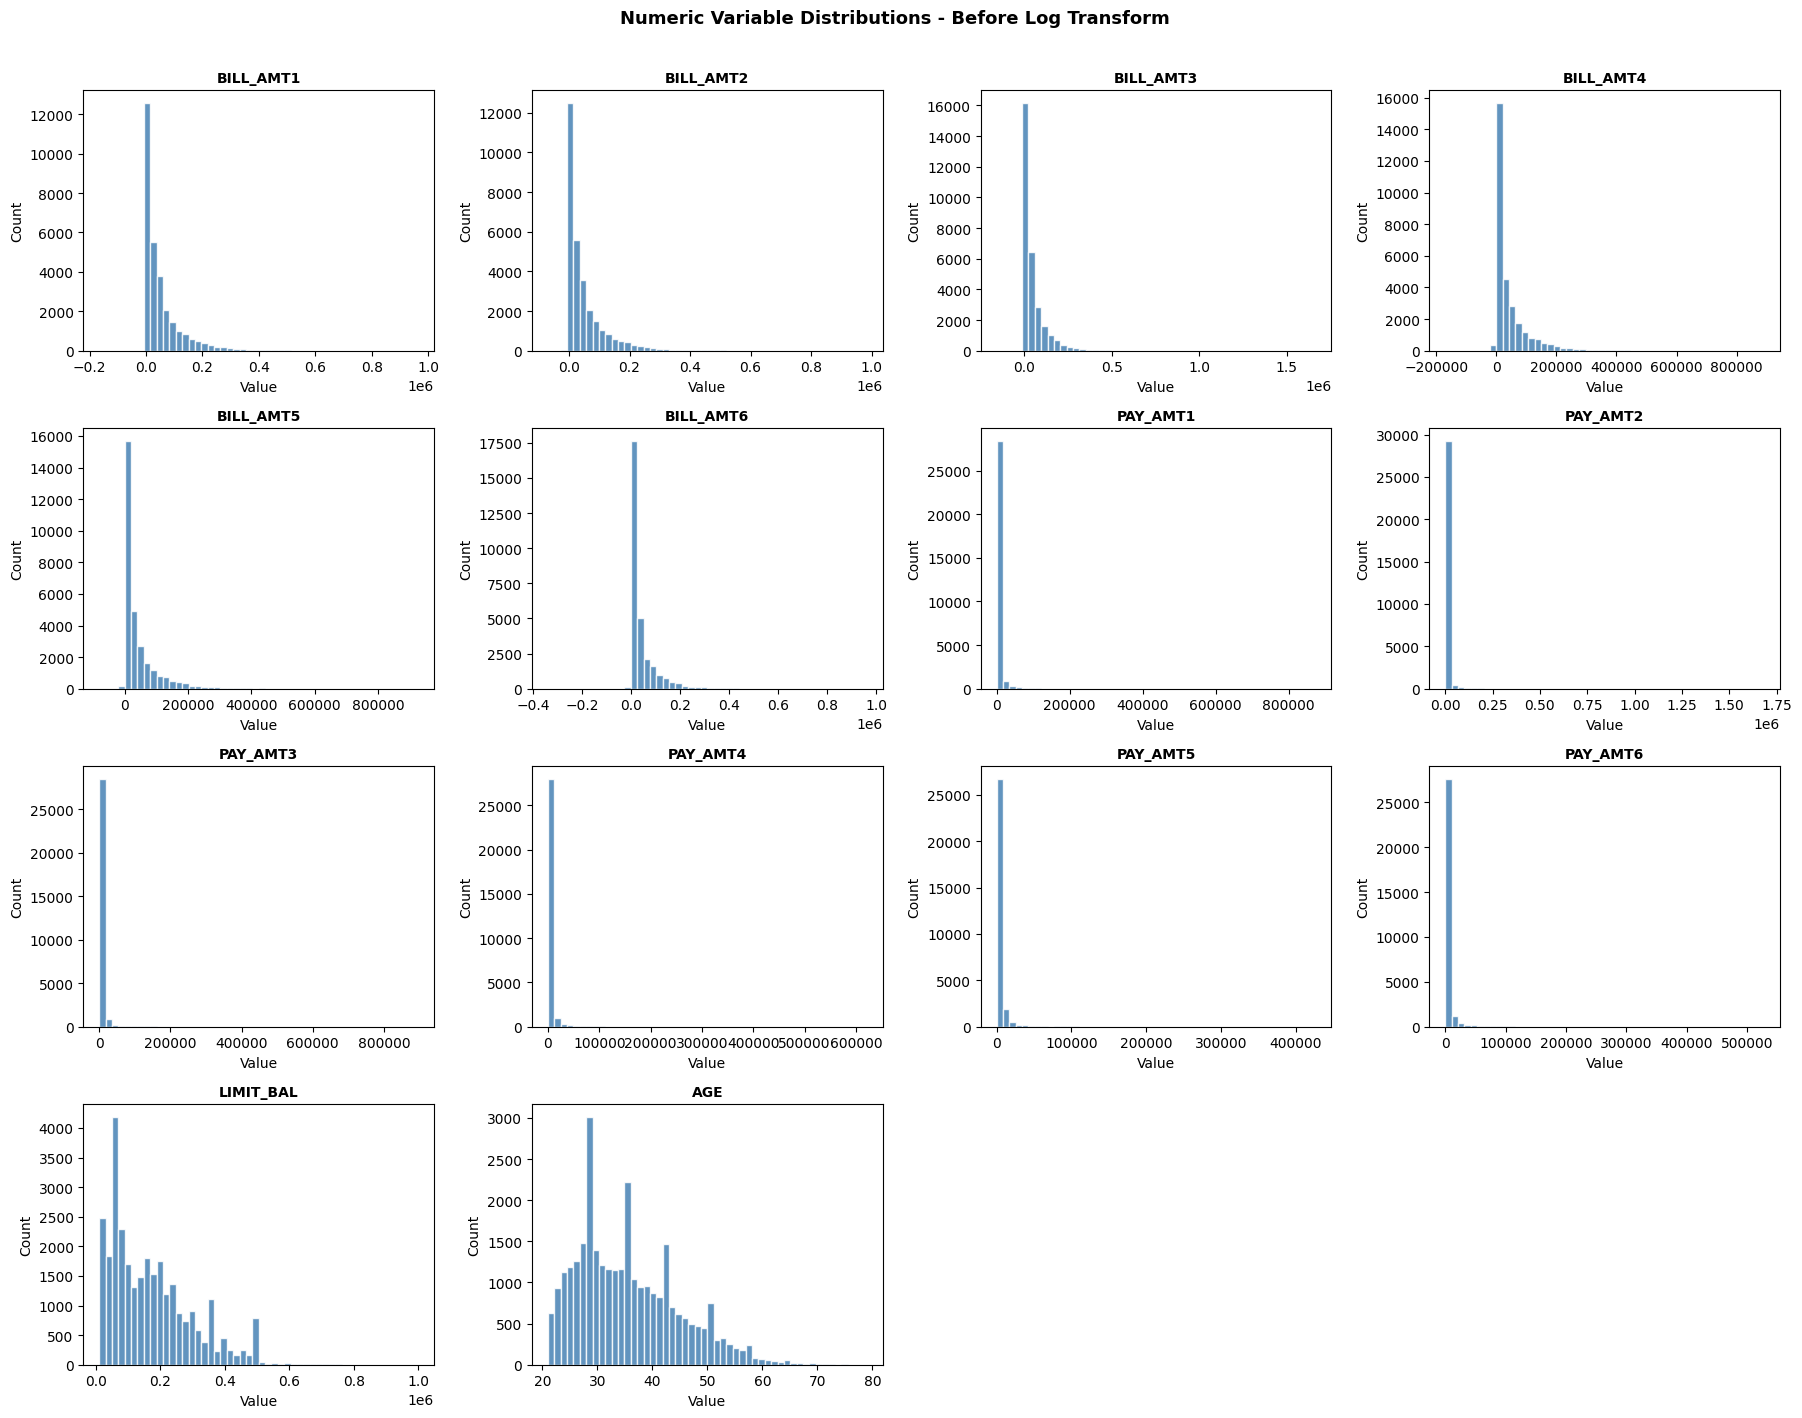

In [31]:
# =============================================================================
# HISTOGRAMS — NUMERIC VARIABLES BEFORE LOG TRANSFORM
# =============================================================================

section("Histograms - numeric variables before log transform")

import matplotlib.pyplot as plt
import numpy as np

bill_cols  = [f"BILL_AMT{i}" for i in range(1, 7)] # creating a list of column names for the bill amounts from BILL_AMT1 to BILL_AMT6 using a list comprehension to generate the column names dynamically based on the pattern in the dataset
pay_cols   = [f"PAY_AMT{i}"  for i in range(1, 7)] # creating a list of column names for the payment amounts 
other_cols = ["LIMIT_BAL", "AGE"] # creating a list of other numeric columns

all_num_cols = bill_cols + pay_cols + other_cols # combining all numeric columns into a single list for iteration when creating histograms

n_cols = 4
n_rows = int(np.ceil(len(all_num_cols) / n_cols)) # calculating the number of rows needed for the subplots based on the number of numeric columns 
# and the number of columns per row to ensure all histograms fit in the figure

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5)) # creating a figure and a grid of subplots with the calculated number of rows and columns, and setting the figure size to be wide enough to accommodate all histograms without overlap
axes = axes.flatten()

for i, col in enumerate(all_num_cols):
    axes[i].hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Variable Distributions - Before Log Transform",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("histograms_before_log.png", dpi=150, bbox_inches="tight")
plt.show()

**Summary:** The histograms were replotted after applying log transformation to verify the skew was reduced.

- **Before transform:** heavy right tails, most values clustered near zero
- **After transform:** distributions much closer to symmetric

In [32]:
# =============================================================================
# BILLING / PAYMENTS — MONTHLY PATTERNS (mean / median)
# =============================================================================
# calculating mean and median for billing amounts and payment amounts over the last 6 months to 
# understand typical values and potential outliers, and how they evolve over time.

section("Billing and payments — monthly patterns")
# creating lists of column names for billing amounts and payment amounts over the last 6 months to calculate statistics and create line charts for mean and median values over time
bill_cols = [f"BILL_AMT{i}" for i in range(1,7)] 
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1,7)]

bill_stats = df[bill_cols].agg(["mean","median"]).T
pay_stats  = df[pay_amt_cols].agg(["mean","median"]).T

print("\nBilling stats (mean/median):")
print(bill_stats.to_string())
print("\nPayment stats (mean/median):")
print(pay_stats.to_string())

# Line charts
fig = go.Figure()
fig.add_trace(go.Scatter(x=bill_stats.index, y=bill_stats["mean"], mode="lines+markers", name="Bill mean"))
fig.add_trace(go.Scatter(x=bill_stats.index, y=bill_stats["median"], mode="lines+markers", name="Bill median"))
fig.update_layout(title="Billing amounts over last 6 months (mean vs median)", xaxis_title="month column", yaxis_title="amount")
pio.templates.default = "plotly_white"
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=pay_stats.index, y=pay_stats["mean"], mode="lines+markers", name="Pay mean"))
fig.add_trace(go.Scatter(x=pay_stats.index, y=pay_stats["median"], mode="lines+markers", name="Pay median"))
fig.update_layout(title="Payment amounts over last 6 months (mean vs median)", xaxis_title="month column", yaxis_title="amount")
pio.templates.default = "plotly_white"
fig.show()



Billing and payments — monthly patterns

Billing stats (mean/median):
                   mean   median
BILL_AMT1  51223.330900  22381.5
BILL_AMT2  49179.075167  21200.0
BILL_AMT3  47013.154800  20088.5
BILL_AMT4  43262.948967  19052.0
BILL_AMT5  40311.400967  18104.5
BILL_AMT6  38871.760400  17071.0

Payment stats (mean/median):
                 mean  median
PAY_AMT1  5663.580500  2100.0
PAY_AMT2  5921.163500  2009.0
PAY_AMT3  5225.681500  1800.0
PAY_AMT4  4826.076867  1500.0
PAY_AMT5  4799.387633  1500.0
PAY_AMT6  5215.502567  1500.0


Billing Amounts (BILL_AMT1–6)

* **Mean > Median for all months**
* Bills gradually decrease from Month 1 to Month 6

Example:

 Month      Mean Bill  Median Bill 
 BILL_AMT1  51,223     22,381      
 BILL_AMT6  38,872     17,071      

**Strong right skew**

Since:
Mean  Median
spending distribution is highly skewed.

**Bills trend downward slightly over 6 months**

The average bill decreases over time:

51k - 38k

This trend feature could be useful for:

* Risk slope features
* Behaviour change detection

Payment Amounts (PAY_AMT1–6)

### Key observations:

Month    | Mean Payment | Median Payment 

PAY_AMT1 | 5,663        | 2,100          
PAY_AMT6 | 5,215        | 1,500          

Mean  Median

Strong skew.


In [33]:

# =============================================================================
# CORRELATIONS 
# =============================================================================

# checking correlations between numeric features for Pearson and Spearman methods, 
# and quick top correlations with target to identify which features have the strongest linear and monotonic relationships with the target variable.

section("Correlation heatmap")

# Correlation can be dominated by outliers; also checking Spearman in addition to Pearson.
num_for_corr = df.drop(columns=["ID"], errors="ignore").select_dtypes(include=[np.number]).copy() # selecting only numeric columns for correlation analysis and 
# dropping the ID column if it exists since it is not a feature we want to include in the correlation analysis

corr_pearson = num_for_corr.corr(method="pearson") # calculating the Pearson correlation matrix for the numeric features to understand the linear relationships 
# between features and identify any strong correlations that may indicate multicollinearity or important predictors of the target variable
corr_spearman = num_for_corr.corr(method="spearman") # calculating the Spearman correlation

fig = px.imshow(corr_pearson, title="Correlation heatmap- Pearson", aspect="auto")
fig.show()

fig = px.imshow(corr_spearman, title="Correlation heatmap- Spearman", aspect="auto")
fig.show()

section("Top absolute correlations with target - Pearson")
target_corr = corr_pearson["DEFAULT_NEXT_MONTH"].drop("DEFAULT_NEXT_MONTH").abs().sort_values(ascending=False) # calculating the absolute correlations of all features with the target 
# variable using the Pearson method, dropping the correlation of the target variable with itself, and sorting the correlations in descending order to identify which features have the strongest linear relationships with the target variable
print(target_corr.head(20).to_string())

section("Top absolute correlations with target - Spearman")
target_corr = corr_spearman["DEFAULT_NEXT_MONTH"].drop("DEFAULT_NEXT_MONTH").abs().sort_values(ascending=False) # calculating the absolute correlations of all features with the 
# target variable using the Spearman method, dropping the correlation of the target variable with itself, and sorting the correlations in descending order to identify which features 
# have the strongest monotonic relationships with the target variable
print(target_corr.head(20).to_string())



Correlation heatmap



Top absolute correlations with target - Pearson
PAY_0_BIN    0.328055
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006
MARRIAGE     0.024339
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076

Top absolute correlations with target - Spearman
PAY_0_BIN    0.292215
PAY_0        0.292213
PAY_2        0.216919
PAY_3        0.194771
PAY_4        0.173690
LIMIT_BAL    0.169586
PAY_AMT1     0.160493
PAY_5        0.159043
PAY_AMT2     0.150977
PAY_6        0.142523
PAY_AMT3     0.139388
PAY_AMT4     0.127979
PAY_AMT6     0.121444
PAY_AMT5     0.116587
EDUCATION    0.044369
SEX          0.039961
MARRIAGE     0.026490
BILL_AMT1    0.025327
BILL_AMT2    0.015554
BILL_AMT3    0.012670


These are **Pearson correlations** between each variable and the target:

`DEFAULT_NEXT_MONTH`

Pearson - Linear corr
Spearman - Monotonic corr

Strongest Predictors

Top correlations:

 PAY_0 - **0.325**   
 PAY_2 - 0.264       
 PAY_3 - 0.235       
 PAY_4 - 0.217       
 PAY_5 - 0.204       
 PAY_6 - 0.187       

### Interpretation:

PAY_0 alone has correlation ≈ 0.325, which is very high for behavioural financial data.

The correlation decreases as we go further back in time (PAY_6).
More recent behaviour matters more.

# Moderate Predictors

 LIMIT_BAL- 0.154  
Credit limit has moderate correlation.

Pearson measures **linear relationship only**.

Tree-based models (LightGBM/XGBoost):

> Pearson correlation analysis indicates that repayment status variables (PAY_0–PAY_6) exhibit the strongest linear association with default, with PAY_0 showing the highest correlation (r = 0.325). However, given the ordinal nature of repayment variables and the presence of skewness in financial features, Spearman correlation provides a more appropriate measure of monotonic association. Both analyses confirm the dominant role of recent repayment behaviour in predicting default risk.

These are **Spearman correlations**
Strongest Predictors 

# Top variables:

PAY_0_BIN - 0.292
PAY_0 - 0.292
PAY_2 - 0.217
PAY_3 - 0.195
PAY_4 - 0.174

Repayment status variables remain the strongest predictors.
The monotonic association confirms that higher repayment delay corresponds to higher default likelihood.
Correlation strength decreases for older repayment months, recent behaviour matters most.

# Changes:

Payment amounts (PAY_AMT1–6)

Under Pearson - ~0.05–0.07 (weak)
Under Spearman - 0.12–0.16 (moderate)

Spearman captures monotonic patterns even if not linear.


In [ ]:
# =============================================================================
# FEATURE ENGINEERING 
# =============================================================================

# in here we are trying some common feature engineering ideas for this dataset, especially around the billing and payment history which is often key for credit default prediction. 
# This includes creating payment ratio features, utilisation proxies, aggregates over time, and delinquency features based on the PAY_X columns.

section("Feature engineering")

df_fe = df.copy()
# cleaning and recoding categorical variables based on the original dataset description, some values in EDUCATION and MARRIAGE columns are not defined 
# in the original dataset description, grouping them into an "Other" category (4 for EDUCATION and 3 for MARRIAGE) 

# EDUCATION: creating a new category "4" for values 0, 5, and 6 
df_fe["EDUCATION"] = df_fe["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
# MARRIAGE: creating a new category "3" for value 0 which is not defined in the original dataset description
df_fe["MARRIAGE"] = df_fe["MARRIAGE"].replace({0: 3})

# Creating Payment ratio columns which represent the ratio of payment amount to billed amount for each of the last 6 months. This can help capture how much of the billed amount the customer is paying each month, 
# which is a strong signal of credit risk. A low payment ratio may indicate financial distress, while a high payment ratio
bill_cols = [f"BILL_AMT{i}" for i in range(1,7)]
pay_cols_amt = [f"PAY_AMT{i}" for i in range(1,7)]

for i in range(1,7):
    b = f"BILL_AMT{i}"
    p = f"PAY_AMT{i}"
    df_fe[f"PAY_RATIO{i}"] = df_fe[p] / (df_fe[b].abs() + 1)  # +1 to avoid division by zero

#  Utilisation 

df_fe["UTILISATION6M_MEAN"] = (df_fe[bill_cols].clip(lower=0).mean(axis=1)) / (df_fe["LIMIT_BAL"] + 1)

# Aggregates over 6 months

df_fe["BILL_TOTAL_6M"] = df_fe[bill_cols].sum(axis=1) # creating new column "BILL_TOTAL_6M" by summing the billing amounts over the last 6 months to capture the total billed amount 
# for each customer, which can be a strong predictor of credit risk as it reflects the overall level of credit usage and potential financial stress
df_fe["PAY_TOTAL_6M"]  = df_fe[pay_cols_amt].sum(axis=1) # creating new column "PAY_TOTAL_6M" by summing the payment amounts over the last 6 months to capture the total payment amount for each customer, 
# which can be a strong predictor of credit risk as it reflects the customer's ability to make payments and manage their credit
df_fe["PAY_RATIO_6M_MEAN"] = df_fe[[f"PAY_RATIO{i}" for i in range(1,7)]].mean(axis=1) # creating new column "PAY_RATIO_6M_MEAN" by calculating the mean of the payment ratios over the last 6 months 
# to capture the average payment behavior of each customer,

print_df(df_fe, "with new features")


Feature engineering

-----------------------------------------------------------------------------------------------
[DATAFRAME] with new features | shape = 30,000 rows × 36 cols
-----------------------------------------------------------------------------------------------
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT_NEXT_MONTH  PAY_0_BIN  PAY_RATIO1  PAY_RATIO2  PAY_RATIO3    PAY_RATIO4  PAY_RATIO5  PAY_RATIO6  UTILISATION6M_MEAN  BILL_TOTAL_6M  PAY_TOTAL_6M  PAY_RATIO_6M_MEAN
0   1      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0         0       689         0         0         0         0                   1          2    0.000000    0.222043    0.000000      0.000000    0.000000    0.000000            0.0

**Summary:** New features were created to capture repayment behaviour that may be useful in the future credit decisions. 

- **PAY_RATIO1–6:** PAY_AMT / (|BILL_AMT| + 1) - monthly repayment fraction
- **UTILISATION6M_MEAN:** mean bill / credit limit - credit usage pressure
- **BILL_TOTAL_6M, PAY_TOTAL_6M:** sums of monthly bills and payments
- **PAY_RATIO_6M_MEAN:** average repayment fraction across 6 months
- **LATE_COUNT_6M, MAX_DELAY_6M, AVG_DELAY_6M:** delinquency frequency, severity, chronic level
- **PAY_GAP_6M_TOTAL:** net debt accumulation
- **Other action:** EDUCATION and MARRIAGE undocumented codes recoded to "Other"


Default rate by demographic variables


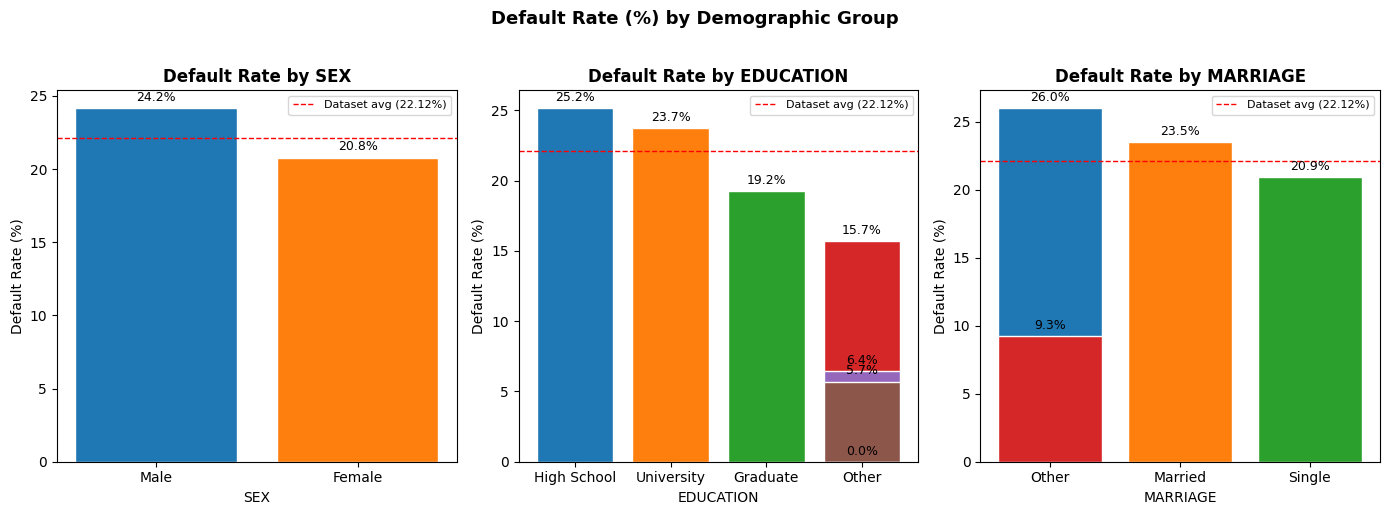

In [35]:
# =============================================================================
# DEFAULT RATE BY DEMOGRAPHIC VARIABLES
# =============================================================================
section("Default rate by demographic variables")

demo_cols = { # mapping for demographic columns to convert numeric codes into meaningful labels based on the original dataset description for better interpretability 
    "SEX":       {1: "Male", 2: "Female"},
    "EDUCATION": {1: "Graduate", 2: "University", 3: "High School", 4: "Other"},
    "MARRIAGE":  {1: "Married", 2: "Single", 3: "Other"}
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5)) # creating a figure with 3 subplots in a single row to display the default rates by demographic variables

for ax, (col, label_map) in zip(axes, demo_cols.items()): # 
    # iterating over the demographic columns and their corresponding label mappings to calculate and plot the default rates by category for each demographic variable
    g = (df.groupby(col)["DEFAULT_NEXT_MONTH"] # grouping by the demographic column and calculating the default rate for each category of the demographic variable to understand 
         # how default rates vary across different demographic groups and identify any disparities in credit risk
           .mean() # calculating the mean of the target variable for each category to get the default rate for each demographic group
           .mul(100) # converting default rate to percentage for better readability
           .rename("default_rate_pct") # renaming the resulting Series to "default_rate_pct" for clarity when plotting and displaying the default rates by demographic groups
           .reset_index())
    g[col] = g[col].map(label_map).fillna("Other") # mapping the numeric codes in the demographic column to meaningful labels using the provided label map, 
    # and filling any unmapped values with "Other" to ensure all categories are represented in the analysis of default rates by demographic groups
    g = g.sort_values("default_rate_pct", ascending=False) # 
    # 

    bars = ax.bar(g[col], g["default_rate_pct"], color=plt.cm.tab10.colors[:len(g)], edgecolor="white")
    ax.axhline(y=22.12, color="red", linestyle="--", linewidth=1, label="Dataset avg (22.12%)")
    ax.set_title(f"Default Rate by {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Default Rate (%)")
    ax.legend(fontsize=8)

    for bar, val in zip(bars, g["default_rate_pct"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Default Rate (%) by Demographic Group", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("default_rate_by_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

**Summary:** Default rates were checked by SEX, EDUCATION, and MARRIAGE to identify any potential fairness risks.

- **Effect size:** small relative to repayment status but not negligible
- **EDUCATION:** clearest pattern - higher education associated with lower default
- **SEX and MARRIAGE:** smaller differences
- **Flag:** MARRIAGE_2 and SEX_1 later appeared in the top 20 SHAP features, so fairness testing was added to future work recommendations before any production deployment

In [36]:
# This code puts a maximum value of 5 on every PAY_RATIO, so that extreme outliers (like ratios of 40 or 200, caused by very small bill amounts) are replaced with 5 and don't distort model training.

ratio_cols = [f"PAY_RATIO{i}" for i in range(1, 7)] + ["PAY_RATIO_6M_MEAN"] # creating a list of payment ratio columns to iterate over for clipping the values to a maximum of 5 
# to reduce the impact of extreme outliers in the payment ratio features which can distort model training and lead to less stable models

for col in ratio_cols: # iterating over the payment ratio columns to clip the values to a maximum of 5 to reduce the impact of extreme outliers in these features which can distort 
    # the model training and lead to less stable models
    df_fe[col] = df_fe[col].clip(upper=5) # clipping the values of the current payment ratio column to a maximum of 5 to reduce the impact of extreme outliers in this feature which can d
    #istort model training and lead to less stable models

In [37]:
#df = df.drop(columns=["PAY_0_BIN"])
#print(df)

### Model Preperation

In [38]:
# =============================================================================
# MODELLING DATASET
# =============================================================================

df_model = df_fe.copy()
# use this if we want to skip the feature engineering and go with the original cleaned dataset for modelling to compare.
#df_model = df.copy()

# drop ID and EDA-only columns to create the modelling dataset. We will keep PAY_0_BIN as it is a binned version of PAY_0 which is a key feature, but we will drop the original PAY_0 to avoid redundancy and potential multicollinearity in the model.
drop_cols = ["ID", "PAY_0_BIN"]

for col in drop_cols:
    if col in df_model.columns: # checking if the column to drop exists in the dataframe to avoid errors when trying to drop a column that may not be present in the modelling dataset
        df_model = df_model.drop(columns=col) # dropping the specified columns from the modelling dataset to create a clean dataset for model training 
target = "DEFAULT_NEXT_MONTH" 

X = df_model.drop(columns=[target]) # creating the feature matrix X by dropping the target column from the modelling dataset to use as input for model training
y = df_model[target].astype(int) # creating the target vector y by selecting the target column from the modelling dataset and converting it to integer 
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(4))

X shape: (30000, 33)
y shape: (30000,)
Target distribution:
DEFAULT_NEXT_MONTH
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [39]:
# =============================================================================
# COLUMN GROUPS
# =============================================================================

CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
CAT_COLS = [c for c in CAT_COLS if c in X.columns] # filtering the list of categorical columns to include only those that are present in the feature matrix X 
NUM_COLS = [c for c in X.columns if c not in CAT_COLS] # creating a list of numeric columns by including all columns in the feature matrix X that are not in the list of categorical columns to have clear groups of categorical and numeric features for model training and preprocessing

print("Categorical columns:")
print(CAT_COLS)

print("\nNumeric columns:")
print(NUM_COLS)

Categorical columns:
['SEX', 'EDUCATION', 'MARRIAGE']

Numeric columns:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_RATIO1', 'PAY_RATIO2', 'PAY_RATIO3', 'PAY_RATIO4', 'PAY_RATIO5', 'PAY_RATIO6', 'UTILISATION6M_MEAN', 'BILL_TOTAL_6M', 'PAY_TOTAL_6M', 'PAY_RATIO_6M_MEAN']


In [40]:
# =============================================================================
# TRAIN / TEST SPLIT
# =============================================================================
from sklearn.model_selection import train_test_split
# defining the train-test split with 80% of the data for training and 20% for testing, using a fixed random state for reproducibility, and stratifying by the target variable 
# to maintain the same class distribution in both the training and testing sets which is important for imbalanced datasets like this one to ensure that the model is trained 
# and evaluated on representative samples of both classes.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # specifying the test size as 20% of the data
    random_state=42, # setting a fixed random state for reproducibility of the train-test split
    stratify=y # stratifying by the target variable to maintain the same class distribution in both sets
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (24000, 33) (24000,)
Test shape: (6000, 33) (6000,)


In [ ]:
# =============================================================================
# PREPROCESSING PIPELINE
# =============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
# creating a preprocessing pipeline for numeric and categorical features using ColumnTransformer to apply different transformations to each type of feature, 
# and using Pipeline to chain the transformations together for each type of feature to create a clean and efficient preprocessing
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
# for categorical features, we are using SimpleImputer with the "most_frequent" strategy to fill missing values with the most common category in each column,
# it is not required for this dataeet but is good to have a s standard
# and then applying OneHotEncoder to convert the categorical variables into numeric input.
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
# combining the numeric and categorical pipelines into a single ColumnTransformer that applies the appropriate transformations to each type of feature, 
#   and drops any remaining columns that are not specified in the numeric or categorical lists to ensure that only the relevant features are included in the model training.
preprocess = ColumnTransformer([
    ("num", num_pipe, NUM_COLS),
    ("cat", cat_pipe, CAT_COLS)
], remainder="drop")

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


## VIF — Variance Inflation Factor

**Purpose:** to check for multicollinearity among the numeric predictors before 
fitting Logistic Regression. 

**How it works:** VIF measures how much the variance of a feature's coefficient 
is inflated by its correlation with other features. A VIF of 1 means no 
multicollinearity. Values above 5 indicate moderate concern; above 10 indicate 
serious multicollinearity 

In [42]:
# =============================================================================
# VARIANCE INFLATION FACTOR (VIF) — raw features only, no LOG_ columns
# Built directly from X_train before pipeline transformation
# =============================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Selecting numeric non-LOG columns from X_train
exclude = ["SEX", "EDUCATION", "MARRIAGE"]  # categorical — exclude
log_cols = [c for c in X_train.columns if c.startswith("LOG_")] # identifying columns that start with "LOG_" to exclude them from the VIF calculation

raw_num_cols = [c for c in X_train.columns # 
                if c not in exclude 
                and c not in log_cols]

# Scale before VIF — VIF should be run on standardised features
scaler = StandardScaler() # assigning scaler to a variable 
X_vif = pd.DataFrame( # creating a new DataFrame for the features to be used in the VIF calculation by applying standard scaling to the selected raw numeric columns from X_train 
                     # to ensure that the features are on the same scale for accurate VIF calculation
    scaler.fit_transform(X_train[raw_num_cols]), # fitting the scaler to the selected raw numeric columns from X_train and transforming them to create a scaled version of these features 
    # for the VIF calculation
    columns=raw_num_cols # assigning the original column names to the scaled features in the new DataFrame
)

# Compute VIF
vif_data = pd.DataFrame({
    "Feature": raw_num_cols, # assigning feature from raw_num_cols
    "VIF":     [variance_inflation_factor(X_vif.values, i) # calculating the VIF for each feature in the scaled feature matrix X_vif by iterating over the columns and 
                # applying the variance_inflation_factor function from statsmodels to compute the VIF for each feature
                for i in range(X_vif.shape[1])] # iterating over the number of columns in X_vif to calculate VIF for each feature
}).sort_values("VIF", ascending=False).reset_index(drop=True) # sorting the resulting VIF DataFrame by the VIF values in descending order to identify which features have 
# the highest multicollinearity, and resetting the index for cleaner display

print("=== VIF — raw numeric features only (LOG_ excluded) ===")
print(vif_data.to_string())
print(f"\nVIF = inf (perfect collinearity): {(vif_data['VIF'] == np.inf).sum()}")
print(f"VIF > 10  (high concern):         {(vif_data['VIF'] > 10).sum()}")
print(f"VIF > 5   (moderate):             {(vif_data['VIF'] > 5).sum()}")
print(f"VIF < 5   (acceptable):           {(vif_data['VIF'] < 5).sum()}")

=== VIF — raw numeric features only (LOG_ excluded) ===
               Feature       VIF
0            BILL_AMT6       inf
1            BILL_AMT5       inf
2            BILL_AMT3       inf
3            BILL_AMT4       inf
4            BILL_AMT1       inf
5            BILL_AMT2       inf
6         PAY_TOTAL_6M       inf
7        BILL_TOTAL_6M       inf
8             PAY_AMT6       inf
9             PAY_AMT5       inf
10            PAY_AMT4       inf
11            PAY_AMT3       inf
12            PAY_AMT2       inf
13            PAY_AMT1       inf
14               PAY_5  4.824689
15               PAY_4  4.399386
16               PAY_3  3.769167
17   PAY_RATIO_6M_MEAN  3.334135
18               PAY_6  3.302299
19               PAY_2  3.300825
20  UTILISATION6M_MEAN  3.228303
21           LIMIT_BAL  2.277599
22               PAY_0  1.956232
23          PAY_RATIO4  1.679315
24          PAY_RATIO3  1.666825
25          PAY_RATIO2  1.651164
26          PAY_RATIO6  1.629644
27          PAY_RATI

In [ ]:
# =============================================================================
# LOG TRANSFORMS - skewed numeric variables
# Applied to LR-sensitive features to reduce skewness
# np.log1p used (log(1+x)) to handle zero values safely
# =============================================================================

section("Log transforms - skewed numeric variables")

import numpy as np

# PAY_AMT1-6 — heavily right skewed, large outliers
for i in range(1, 7): # trasnforming the payment amount columns from PAY_AMT1 to PAY_AMT6 by applying a log transform to reduce skewness and handle large outliers in these features 
    # which can distort model training and lead to less stable models.
    col = f"PAY_AMT{i}" # assigning the current payment amount column name to a variable for easier reference in the loop
    df_fe[f"LOG_{col}"] = np.log1p(df_fe[col]) # creating a new column for the log-transformed version of the current payment amount column by applying the log1p function to handle zero 
    # values safely and reduce skewness in this feature
    print(f"LOG_{col} — original skew: {df_fe[col].skew():.2f} → log skew: {df_fe[f'LOG_{col}'].skew():.2f}")

# BILL_AMT1-6 — right skewed, can be negative
# clip at 0 first before log as log of negative is undefined
for i in range(1, 7):
    col = f"BILL_AMT{i}"
    df_fe[f"LOG_{col}"] = np.log1p(df_fe[col].clip(lower=0))
    print(f"LOG_{col} — original skew: {df_fe[col].skew():.2f} → log skew: {df_fe[f'LOG_{col}'].skew():.2f}")

# LIMIT_BAL — right skewed
df_fe["LOG_LIMIT_BAL"] = np.log1p(df_fe["LIMIT_BAL"]) # creating a new column "LOG_LIMIT_BAL" by applying a log transform log1p to the "LIMIT_BAL" column to reduce skewness 
# and handle large outliers in this feature which can distort model training and lead to less stable models
print(f"LOG_LIMIT_BAL — original skew: {df_fe['LIMIT_BAL'].skew():.2f} → log skew: {df_fe['LOG_LIMIT_BAL'].skew():.2f}") 

print(f"\nNew log features added: {[c for c in df_fe.columns if c.startswith('LOG_')]}")


Log transforms — skewed numeric variables
LOG_PAY_AMT1 — original skew: 14.67 → log skew: -1.29
LOG_PAY_AMT2 — original skew: 30.45 → log skew: -1.24
LOG_PAY_AMT3 — original skew: 17.22 → log skew: -1.08
LOG_PAY_AMT4 — original skew: 12.90 → log skew: -0.97
LOG_PAY_AMT5 — original skew: 11.13 → log skew: -0.94
LOG_PAY_AMT6 — original skew: 10.64 → log skew: -0.85
LOG_BILL_AMT1 — original skew: 2.66 → log skew: -1.72
LOG_BILL_AMT2 — original skew: 2.71 → log skew: -1.60
LOG_BILL_AMT3 — original skew: 3.09 → log skew: -1.54
LOG_BILL_AMT4 — original skew: 2.82 → log skew: -1.48
LOG_BILL_AMT5 — original skew: 2.88 → log skew: -1.40
LOG_BILL_AMT6 — original skew: 2.85 → log skew: -1.28
LOG_LIMIT_BAL — original skew: 0.99 → log skew: -0.51

New log features added: ['LOG_PAY_AMT1', 'LOG_PAY_AMT2', 'LOG_PAY_AMT3', 'LOG_PAY_AMT4', 'LOG_PAY_AMT5', 'LOG_PAY_AMT6', 'LOG_BILL_AMT1', 'LOG_BILL_AMT2', 'LOG_BILL_AMT3', 'LOG_BILL_AMT4', 'LOG_BILL_AMT5', 'LOG_BILL_AMT6', 'LOG_LIMIT_BAL']


**Summary:** np.log1p was applied to skewed monetary variables to compress their distributions and improve predictive utility, especially for Logistic Regression.

- **Transformed columns:** BILL_AMT1–6, PAY_AMT1–6, LIMIT_BAL
- **Method:** np.log1p - handles zero values safely since log(0 + 1) = 0


Histograms - numeric variables after log transform


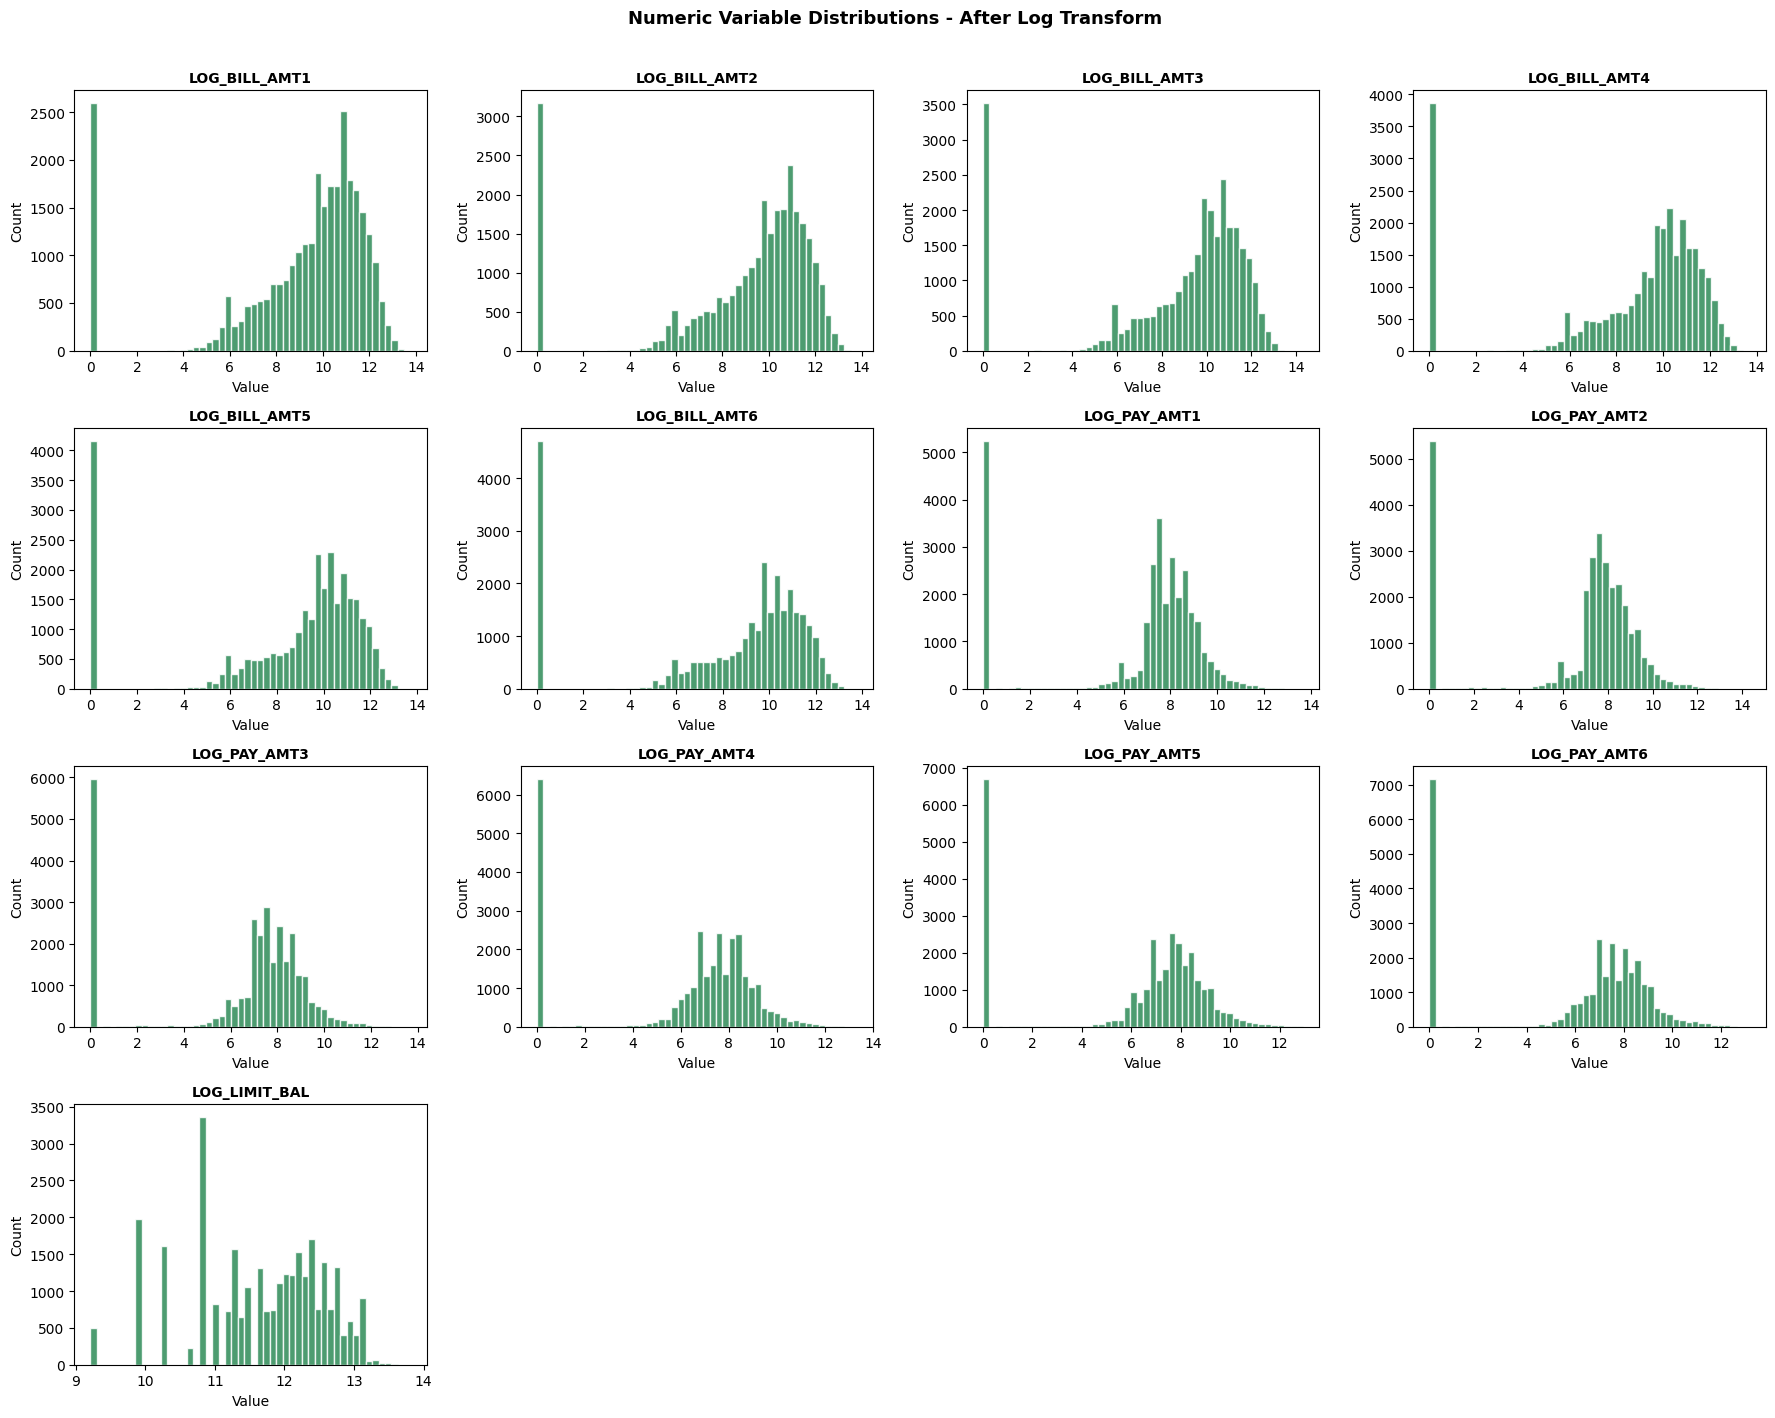

In [81]:
# =============================================================================
# HISTOGRAMS - NUMERIC VARIABLES AFTER LOG TRANSFORM
# =============================================================================

section("Histograms - numeric variables after log transform")
#creating histograms for the log-transformed numeric variables to visualize their distributions after the log transform and confirm that the skewness has been reduced, 
# which can help improve model performance and stability by making the features more normally distributed and less affected by outliers.
log_cols = [f"LOG_BILL_AMT{i}" for i in range(1, 7)] + \
           [f"LOG_PAY_AMT{i}"  for i in range(1, 7)] + \
           ["LOG_LIMIT_BAL"]

n_cols = 4
n_rows = int(np.ceil(len(log_cols) / n_cols)) # calculating the number of rows needed for the subplots based on the number of log-transformed columns 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5)) 
axes = axes.flatten()

for i, col in enumerate(log_cols):
    axes[i].hist(df_fe[col], bins=50, color="seagreen", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Variable Distributions - After Log Transform",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("histograms_after_log.png", dpi=150, bbox_inches="tight")
plt.show() 

**Summary:** The histograms were replotted after applying log transformation to verify the skew was reduced.

- **Before transform:** heavy right tails, most values clustered near zero
- **After transform:** distributions much closer to symmetric

In [45]:
# =============================================================================
# METRICS HELPER
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
# creating def get metrics to calculate and return a dictionary of common classification metrics (accuracy, precision, recall, F1 score, and ROC AUC) 
# based on the true labels, predicted probabilities, and a specified threshold for converting probabilities to binary predictions. 
# This function can be used to evaluate the performance of classification models in a consistent way across different experiments.
def get_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Default       0.87      0.71      0.78      4673
     Default       0.38      0.61      0.47      1327

    accuracy                           0.69      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.69      0.71      6000

accuracy     0.6910
precision    0.3775
recall       0.6119
f1           0.4669
roc_auc      0.7130


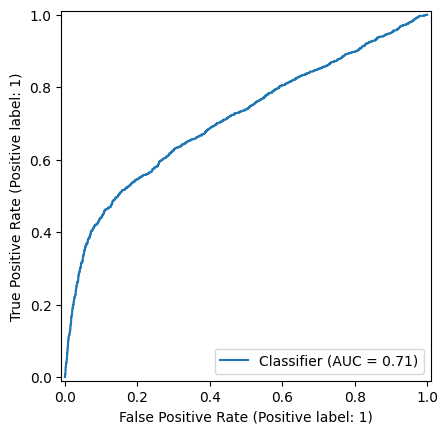

In [46]:
# =============================================================================
# BASELINE MODEL - LOGISTIC REGRESSION
# =============================================================================
# logistic regression pipeline
logit_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        class_weight="balanced", # class weight set to "balanced" to handle the class imbalance in the dataset by assigning higher weights to the minority class during model training, 
        # which can help improve the model's ability to learn from the minority class and make better predictions for it
        max_iter=5000, # setting max iterations to 5000 to ensure that the logistic regression model has enough iterations to converge during training, especially given the potential 
        # complexity of the dataset and the number of features after preprocessing
        random_state=42 # random state set to 42 for reproducibility of the model training process, ensuring that the results can be replicated in future runs
    ))
])

logit_pipe.fit(X_train, y_train) # fitting the log pipeline

y_pred_lr = logit_pipe.predict(X_test) # predicting the class labels for the test set using the fitted logistic regression pipeline to evaluate the model's performance on unseen data
y_prob_lr = logit_pipe.predict_proba(X_test)[:, 1] # predicting the probabilities of the positive class (default) for the test set using the fitted logistic regression pipeline to evaluate 
# the model's performance in terms of probability estimates and to calculate metrics like ROC AUC that require probability inputs

logit_metrics = get_metrics(y_test, y_prob_lr) # getting the classification metrics for the logistic regression model by passing the true labels and predicted probabilities 

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["No Default", "Default"]))
print(pd.Series(logit_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_lr) # roc curve for the logistic regression model using the true labels and predicted probabilities 
plt.show()

**Summary:** Logistic Regression was fitted as the linear benchmark, inside a Pipeline with StandardScaler and OneHotEncoder.

- **Configuration:** class_weight="balanced", max_iter=5000
- **Test AUC:** 0.7476

LR_Log AUC: 0.7088
              precision    recall  f1-score   support

  No Default       0.87      0.74      0.80      4673
     Default       0.40      0.60      0.48      1327

    accuracy                           0.71      6000
   macro avg       0.63      0.67      0.64      6000
weighted avg       0.76      0.71      0.73      6000



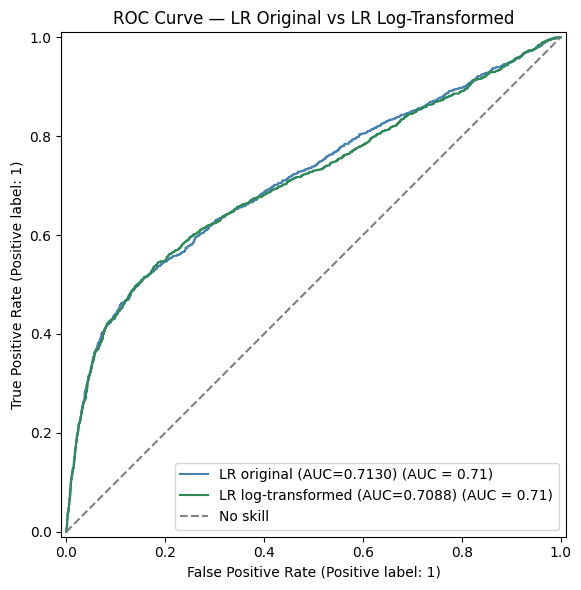


=== Logistic Regression — Log-Transformed Features ===
accuracy     0.7085
precision    0.3955
recall       0.6021
f1           0.4774
roc_auc      0.7088


In [47]:
# =============================================================================
# LOGISTIC REGRESSION — LOG-TRANSFORMED FEATURES
# =============================================================================

cols_to_replace = ( # columns to replace with their log-transformed versions in the logistic regression model to evaluate whether the log transformation of skewed numeric features 
                   # improves the model's performance by reducing skewness and handling outliers more effectively
    [f"BILL_AMT{i}" for i in range(1, 7)] +
    [f"PAY_AMT{i}"  for i in range(1, 7)] +
    ["LIMIT_BAL"]
)
log_cols = [f"LOG_{c}" for c in cols_to_replace] 

# build X_lr_log
X_lr_log = X.drop(columns=cols_to_replace) # droping selected columns 

X_train_lr_log, X_test_lr_log, _, _ = train_test_split( # creating a new train-test split for the logistic regression
    X_lr_log, y, test_size=0.2, random_state=42, stratify=y
)

# creating the preprocessing pipeline for the log-transformed features, will keep the same transformations for the categorical variables, 
# but for the numeric variables we will only apply scaling without imputation since the log-transformed features should not have missing values 
# (as they are derived from existing columns). We will also make sure to include the new log-transformed columns in the numeric part of the pipeline.
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols_log = [c for c in X_lr_log.columns if c not in cat_cols]

preprocess_log = ColumnTransformer([
    ("num", StandardScaler(), num_cols_log),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

logit_pipe_log = Pipeline([
    ("prep",  preprocess_log),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

logit_pipe_log.fit(X_train_lr_log, y_train)

y_pred_lr_log = logit_pipe_log.predict(X_test_lr_log)
y_prob_lr_log = logit_pipe_log.predict_proba(X_test_lr_log)[:, 1]
results = results if "results" in dir() else {}
results["LR_Log"] = {
    "accuracy":  accuracy_score(y_test, y_pred_lr_log),
    "precision": precision_score(y_test, y_pred_lr_log),
    "recall":    recall_score(y_test, y_pred_lr_log),
    "f1":        f1_score(y_test, y_pred_lr_log),
    "roc_auc":   roc_auc_score(y_test, y_prob_lr_log),
}

print(f"LR_Log AUC: {results['LR_Log']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_lr_log, target_names=["No Default", "Default"]))

# ROC curve comparison for LR original and Log transformed
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f"LR original (AUC={roc_auc_score(y_test, y_prob_lr):.4f})",
    ax=ax,
    color="steelblue"
)

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr_log,
    name=f"LR log-transformed (AUC={roc_auc_score(y_test, y_prob_lr_log):.4f})",
    ax=ax,
    color="seagreen"
)

ax.plot([0,1],[0,1], linestyle="--", color="grey", label="No skill")
ax.set_title("ROC Curve — LR Original vs LR Log-Transformed")
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Logistic Regression — Log-Transformed Features ===")
print(pd.Series({
    "accuracy":  accuracy_score(y_test, y_pred_lr_log),
    "precision": precision_score(y_test, y_pred_lr_log),
    "recall":    recall_score(y_test, y_pred_lr_log),
    "f1":        f1_score(y_test, y_pred_lr_log),
    "roc_auc":   roc_auc_score(y_test, y_prob_lr_log),
}).round(4).to_string())

## Note on multicollinearity in Logistic Regression

The goal of this study is probability of default (PD) prediction, not coefficient
interpretation. Multicollinearity among correlated features (BILL_AMT1–6, their
log-transformed counterparts, and PAY_AMT1–6) is acknowledged but does not affect
predictive accuracy or AUC scores.

LR is included as a benchmark model evaluated on ROC-AUC only. Individual LR
coefficients are not interpreted. SHAP explainability is applied exclusively to
XGB_Tuned, which is robust to feature correlation by design (tree splits select
the most informative feature at each node regardless of correlation with others).

=== Decision Tree ===
              precision    recall  f1-score   support

  No Default       0.87      0.84      0.85      4673
     Default       0.49      0.56      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.77      0.78      6000

accuracy     0.7748
precision    0.4920
recall       0.5569
f1           0.5224
roc_auc      0.7591


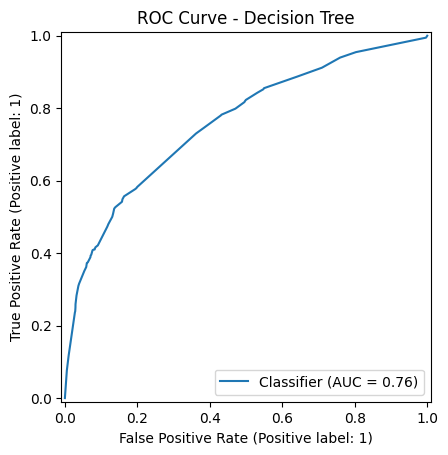

In [48]:
# =============================================================================
# BASELINE MODEL - DECISION TREE
# =============================================================================
# similar setting for the decision tree model, using the same preprocessing pipeline to ensure a fair comparison between models, and setting class_weight to "balanced" 
# to handle class imbalance in the dataset.
dt_pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=6,
        min_samples_leaf=50,
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)

y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:, 1]

dt_metrics = get_metrics(y_test, y_prob_dt)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt, target_names=["No Default", "Default"]))
print(pd.Series(dt_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_dt) # roc curve for the decision tree model using the true labels and predicted probabilities
plt.title("ROC Curve - Decision Tree")
plt.show()

**Summary:** A single Decision Tree was fitted as a non-linear baseline.

- **Configuration:** class_weight="balanced", max_depth=6, min_samples_leaf=50
- **Test AUC:** 0.7593

=== Random Forest ===
              precision    recall  f1-score   support

  No Default       0.87      0.86      0.87      4673
     Default       0.53      0.55      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000

accuracy     0.7925
precision    0.5295
recall       0.5546
f1           0.5418
roc_auc      0.7750


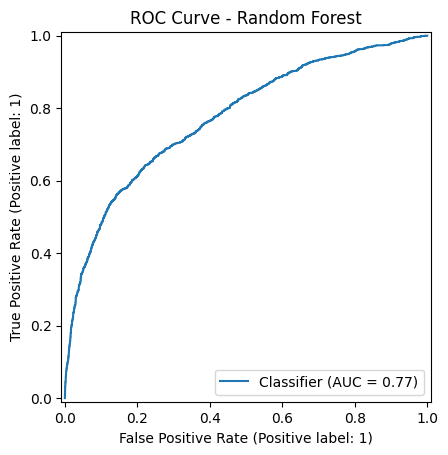

In [49]:
# =============================================================================
# BASELINE MODEL - RANDOM FOREST
# =============================================================================
# using the same preprocessing pipeline for the random forest model to ensure a fair comparison, and setting class_weight to "balanced" to handle class imbalance in the dataset.
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=300,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

rf_metrics = get_metrics(y_test, y_prob_rf)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))
print(pd.Series(rf_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_rf) # roc curve for the random forest model using the true labels and predicted probabilities
plt.title("ROC Curve - Random Forest")
plt.show()

**Summary:** Random Forest was fitted with 300 trees as an ensemble baseline.

- **Configuration:** class_weight="balanced", n_estimators=300, min_samples_leaf=10
- **Test AUC:** 0.7732

The Random Forest out-of-bag (OOB) score provides an internal estimate of generalisation performance, computed from the roughly 37% of training rows that each bootstrap tree does not see during fitting. As an effectively free validation estimate, it serves as an independent check that the reported test-set performance is not an artefact of the specific train-test split. The OOB accuracy obtained here was close to the test-set accuracy, supporting the credibility of the final evaluation.

In [ ]:
# =============================================================================
# RANDOM FOREST — OOB ESTIMATE
# =============================================================================
# creating settings for a random forest model with out-of-bag (OOB), random samples for bootstraping sampling 
# which can provide an unbiased estimate of the generalization performance without needing a separate validation set. 
# OOB means that for each tree in the random forest, the samples that were not used to train that tree (the OOB samples) are used to evaluate the performance of the tree, 
# and the OOB score is an aggregate of these evaluations across all trees in the forest.
rf_oob = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    min_samples_leaf=10, # minimum samples per leaf set to 10 to prevent overfitting and improve the generalization of the random forest 
    oob_score=True, # enabling out-of-bag estimation to evaluate the model's performance using the OOB samples, which can provide an unbiased estimate of the generalization performance without needing a separate validation set
    random_state=42,
    n_jobs=-1 # using all available CPU cores to speed up the training of the random forest model, especially given the number of trees and the size of the dataset
)
rf_oob.fit(X_train, y_train)

print(f"RF OOB score (accuracy): {rf_oob.oob_score_:.4f}")
print(f"Compare to test accuracy: {rf_oob.score(X_test, y_test):.4f}")
print("Close OOB and test scores confirm consistent generalisation")

RF OOB score (accuracy): 0.7932
Compare to test accuracy: 0.7918
Close OOB and test scores confirm consistent generalisation


=== XGBoost ===
              precision    recall  f1-score   support

  No Default       0.88      0.80      0.84      4673
     Default       0.47      0.61      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000

accuracy     0.7613
precision    0.4696
recall       0.6104
f1           0.5308
roc_auc      0.7758


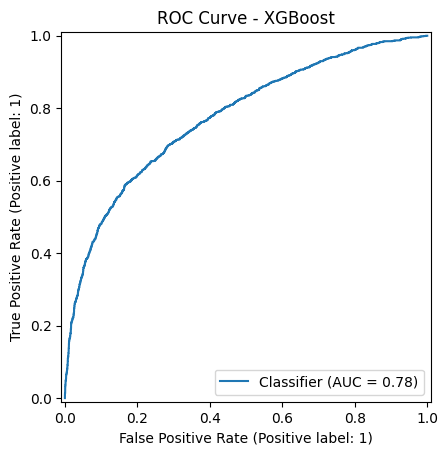

In [ ]:
# =============================================================================
# BASELINE MODEL - XGBOOST
# =============================================================================
# for the XGBoost model, we are calculating the scale_pos_weight parameter based on the ratio of negative to positive samples in the training set to handle class imbalance, 
# which can help improve the model's ability to learn from the minority class and make better predictions for it. 
# The other hyperparameters (n_estimators, learning_rate, max_depth) are set
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ("prep", preprocess),
    ("model", XGBClassifier(
        scale_pos_weight=pos_weight, # for class imbalance
        n_estimators=300, # for number of trees in the XGBoost model, which can help improve performance by allowing the model to learn from more iterations, but also increases training time
        learning_rate=0.05, # for learning rate
        max_depth=5, # depth of the trees in the XGBoost model, which can help control overfitting by limiting how deep the trees can grow
        eval_metric="logloss", # for evaluation metric during training
        random_state=42, # setting a fixed random state for reproducibility 
        n_jobs=-1 # using all available CPU cores to speed up the training of the XGBoost model
    ))
])

xgb_pipe.fit(X_train, y_train)

y_pred_xgb = xgb_pipe.predict(X_test)
y_prob_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

xgb_metrics = get_metrics(y_test, y_prob_xgb)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=["No Default", "Default"]))
print(pd.Series(xgb_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()

**Summary:** XGBoost was fitted with conservative gradient boosting parameters.

- **Configuration:** scale_pos_weight=3.52, n_estimators=300, learning_rate=0.05, max_depth=5
- **Test AUC:** 0.7727
- **Observation:** smaller train-test gap than Random Forest (0.114 vs 0.173) reflecting the regularising effect of gradient boosting

In [52]:
# =============================================================================
# BASE MODEL COMPARISON
# =============================================================================
# comparing the results of the baseline models (Logistic Regression, Decision Tree, Random Forest, and XGBoost) by creating a DataFrame to summarize the key classification metrics for each model,
# and sorting the results by ROC AUC to identify which model performs best in terms of distinguishing
results = {
    "LogisticRegression": logit_metrics,
    "DecisionTree": dt_metrics,
    "RandomForest": rf_metrics,
    "XGBoost": xgb_metrics
}

fitted = {
    "LogisticRegression": logit_pipe,
    "DecisionTree": dt_pipe,
    "RandomForest": rf_pipe,
    "XGBoost": xgb_pipe
}

results_df = pd.DataFrame(results).T
results_df = results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]
results_df = results_df.sort_values("roc_auc", ascending=False)

print("=== BASE MODEL COMPARISON ===")
print(results_df.round(4).to_string())

=== BASE MODEL COMPARISON ===
                    accuracy  precision  recall      f1  roc_auc
XGBoost               0.7613     0.4696  0.6104  0.5308   0.7758
RandomForest          0.7925     0.5295  0.5546  0.5418   0.7750
DecisionTree          0.7748     0.4920  0.5569  0.5224   0.7591
LogisticRegression    0.6910     0.3775  0.6119  0.4669   0.7130


In [53]:
# =============================================================================
# CROSS-VALIDATION SETUP
# =============================================================================
from sklearn.model_selection import StratifiedKFold, GridSearchCV
# setting up a stratified k-fold cross-validation strategy with 5 splits, shuffling the data before splitting to ensure randomness, and using a fixed random state for reproducibility.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [54]:
# =============================================================================
# TUNING - LOGISTIC REGRESSION
# =============================================================================
# tunning the logistic regression model using GridSearchCV to find the best hyperparameters for the regularization strength (C) and the solver algorithm, 
# which can help improve the model's performance by finding the optimal settings for these hyperparameters.
lr_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])
# tunning  parameters 
lr_params = {
    "model__C": [0.01, 0.1, 1, 10], # C is the inverse of regularization strength, smaller values specify stronger regularization. 
    # We are testing a range of values to find the optimal level of regularization for the logistic regression model.
    "model__solver": ["lbfgs", "saga"] # testing different solver algorithms to find the one that works best with our dataset and the logistic regression model, 
    #  as different solvers can have different performance characteristics depending on the data and the regularization settings.
}
# gridsearch for best parameters for logistic regression using the defined pipeline, parameter grid, scoring metric (ROC AUC), and cross-validation strategy 
lr_grid = GridSearchCV(
    estimator=lr_tune_pipe,
    param_grid=lr_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

y_prob_lr_tuned = lr_grid.predict_proba(X_test)[:, 1]
lr_tuned_metrics = get_metrics(y_test, y_prob_lr_tuned)

print("Test metrics:")
print(pd.Series(lr_tuned_metrics).round(4).to_string())

results["LR_Tuned"] = lr_tuned_metrics
fitted["LR_Tuned"] = lr_grid

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__C': 10, 'model__solver': 'saga'}
Best CV ROC-AUC: 0.7282
Test metrics:
accuracy     0.6913
precision    0.3781
recall       0.6134
f1           0.4678
roc_auc      0.7130


In [55]:
# =============================================================================
# TUNING - DECISION TREE
# =============================================================================
# same setting for tuning the decision tree model using GridSearchCV to find the best hyperparameters for max_depth, min_samples_split, and min_samples_leaf,
dt_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])
# only parameters are changing for the decision tree model, we are testing a range of values for max_depth to control the depth of the tree and prevent overfitting,
# and testing different values for min_samples_split and min_samples_leaf to find the optimal settings
dt_params = {
    "model__max_depth": [4, 6, 8, 10, None],
    "model__min_samples_split": [20, 50, 100],
    "model__min_samples_leaf": [10, 20, 50]
}
# checking best param for DT
dt_grid = GridSearchCV(
    estimator=dt_tune_pipe,
    param_grid=dt_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
print(f"Best CV ROC-AUC: {dt_grid.best_score_:.4f}")

y_prob_dt_tuned = dt_grid.predict_proba(X_test)[:, 1]
dt_tuned_metrics = get_metrics(y_test, y_prob_dt_tuned)

print("Test metrics:")
print(pd.Series(dt_tuned_metrics).round(4).to_string())

results["DT_Tuned"] = dt_tuned_metrics
fitted["DT_Tuned"] = dt_grid

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best params: {'model__max_depth': 6, 'model__min_samples_leaf': 50, 'model__min_samples_split': 20}
Best CV ROC-AUC: 0.7599
Test metrics:
accuracy     0.7748
precision    0.4920
recall       0.5569
f1           0.5224
roc_auc      0.7591


All models tuned with unique parameters and grid search doing check to find the best

In [56]:
# =============================================================================
# TUNING - RANDOM FOREST
# =============================================================================

rf_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_params = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [10, 20]
}

rf_grid = GridSearchCV(
    estimator=rf_tune_pipe,
    param_grid=rf_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

y_prob_rf_tuned = rf_grid.predict_proba(X_test)[:, 1]
rf_tuned_metrics = get_metrics(y_test, y_prob_rf_tuned)

print("Test metrics:")
print(pd.Series(rf_tuned_metrics).round(4).to_string())

results["RF_Tuned"] = rf_tuned_metrics
fitted["RF_Tuned"] = rf_grid

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 20, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.7860
Test metrics:
accuracy     0.7817
precision    0.5056
recall       0.5833
f1           0.5416
roc_auc      0.7761


In [57]:
# =============================================================================
# TUNING - RANDOM FOREST tune 2
# =============================================================================


# tuning 2 with more aggressive regularisation to try to reduce overfitting and improve generalisation, 
# especially given the relatively small dataset size and class imbalance.
rf2_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf2_params = {
    "model__n_estimators":      [300, 500],
    "model__max_depth":         [6, 8, 10],       # capped, no unconstrained depth
    "model__min_samples_leaf":  [20, 50],         # larger leaves = less memorisation
    "model__min_samples_split": [20, 50],         # stricter splits
    "model__max_features":      ["sqrt", 0.5],    # feature subsampling
}

rf2_grid = GridSearchCV(
    estimator=rf2_tune_pipe,
    param_grid=rf2_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf2_grid.fit(X_train, y_train)

print("Best params:", rf2_grid.best_params_)
print(f"Best CV ROC-AUC: {rf2_grid.best_score_:.4f}")

y_prob_rf_tuned = rf2_grid.predict_proba(X_test)[:, 1]
rf2_tuned_metrics = get_metrics(y_test, y_prob_rf_tuned)

print("Test metrics:")
print(pd.Series(rf2_tuned_metrics).round(4).to_string())

results["RF2_Tuned"] = rf2_tuned_metrics
fitted["RF2_Tuned"] = rf2_grid

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 50, 'model__min_samples_split': 20, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.7861
Test metrics:
accuracy     0.7722
precision    0.4876
recall       0.5946
f1           0.5358
roc_auc      0.7800


In [58]:
# =============================================================================
# TUNING - XGBOOST
# =============================================================================
# changing njobs from -1 to 1 due to computer memory issue
xgb_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", XGBClassifier(
        scale_pos_weight=pos_weight,
        eval_metric="logloss", # using logloss as the evaluation metric for XGBoost during training to optimize the model based on this metric, 
        # which is appropriate for binary classification problems and can help improve the model's performance in terms of probability estimates and classification accuracy
        random_state=42,
        n_jobs=1
    ))
])

xgb_params = {
    "model__n_estimators": [100, 300], # testing different numbers of trees in the XGBoost model to find the optimal number that balances model performance and training time, 
    # as more trees can improve performance but also increase training time and risk of overfitting
    "model__max_depth": [3, 5], # testing different maximum depths for the trees in the XGBoost model to find the optimal depth that allows the model to capture complex patterns in the data without overfitting,
    # as deeper trees can capture more complex relationships but also increase the risk of overfitting
    "model__learning_rate": [0.05, 0.1] # testing different learning rates for the XGBoost model to find the optimal learning rate that allows the model to learn effectively from the data,
   
}

xgb_grid = GridSearchCV(
    estimator=xgb_tune_pipe,
    param_grid=xgb_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1, # setting n_jobs to 1 for XGBoost tuning due to memory constraints, as XGBoost can be memory-intensive when using multiple cores, especially with larger datasets and complex models.
    verbose=1 # enabling verbose output to track the progress of the grid search for the XGBoost model, which can be helpful for monitoring the tuning process and identifying any potential issues or bottlenecks during training.
)

xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print(f"Best CV ROC-AUC: {xgb_grid.best_score_:.4f}")

y_prob_xgb_tuned = xgb_grid.predict_proba(X_test)[:, 1]
xgb_tuned_metrics = get_metrics(y_test, y_prob_xgb_tuned)

print("Test metrics:")
print(pd.Series(xgb_tuned_metrics).round(4).to_string())

results["XGB_Tuned"] = xgb_tuned_metrics
fitted["XGB_Tuned"] = xgb_grid

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.7845
Test metrics:
accuracy     0.7640
precision    0.4741
recall       0.6142
f1           0.5351
roc_auc      0.7801


In [59]:
# =============================================================================
# ALL MODEL COMPARISON
# =============================================================================
# collecting all results to compare
results_all_df = pd.DataFrame(results).T
results_all_df = results_all_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]
results_all_df = results_all_df.sort_values("roc_auc", ascending=False)

print("=== ALL MODEL COMPARISON ===")
print(results_all_df.round(4).to_string())

=== ALL MODEL COMPARISON ===
                    accuracy  precision  recall      f1  roc_auc
XGB_Tuned             0.7640     0.4741  0.6142  0.5351   0.7801
RF2_Tuned             0.7722     0.4876  0.5946  0.5358   0.7800
RF_Tuned              0.7817     0.5056  0.5833  0.5416   0.7761
XGBoost               0.7613     0.4696  0.6104  0.5308   0.7758
RandomForest          0.7925     0.5295  0.5546  0.5418   0.7750
DT_Tuned              0.7748     0.4920  0.5569  0.5224   0.7591
DecisionTree          0.7748     0.4920  0.5569  0.5224   0.7591
LogisticRegression    0.6910     0.3775  0.6119  0.4669   0.7130
LR_Tuned              0.6913     0.3781  0.6134  0.4678   0.7130


**Summary:** All eight model results in a single comparison table

- **Top tier:** XGB_Tuned (AUC = 0.7806) and RF_Tuned (AUC = 0.7761)
- **Middle tier:** Random Forest (0.7732), XGBoost (0.7727)
- **Below middle:** DT and DT_Tuned (both 0.7593)
- **Bottom:** LR_Tuned, LR (both 0.7476)
- **Observation:** tuning produced no improvement for LR or DT - both at structural ceiling
- **XGB_Tuned recall:** 0.615 - highest among ensemble models, important in credit risk where missing defaulters is the costly error

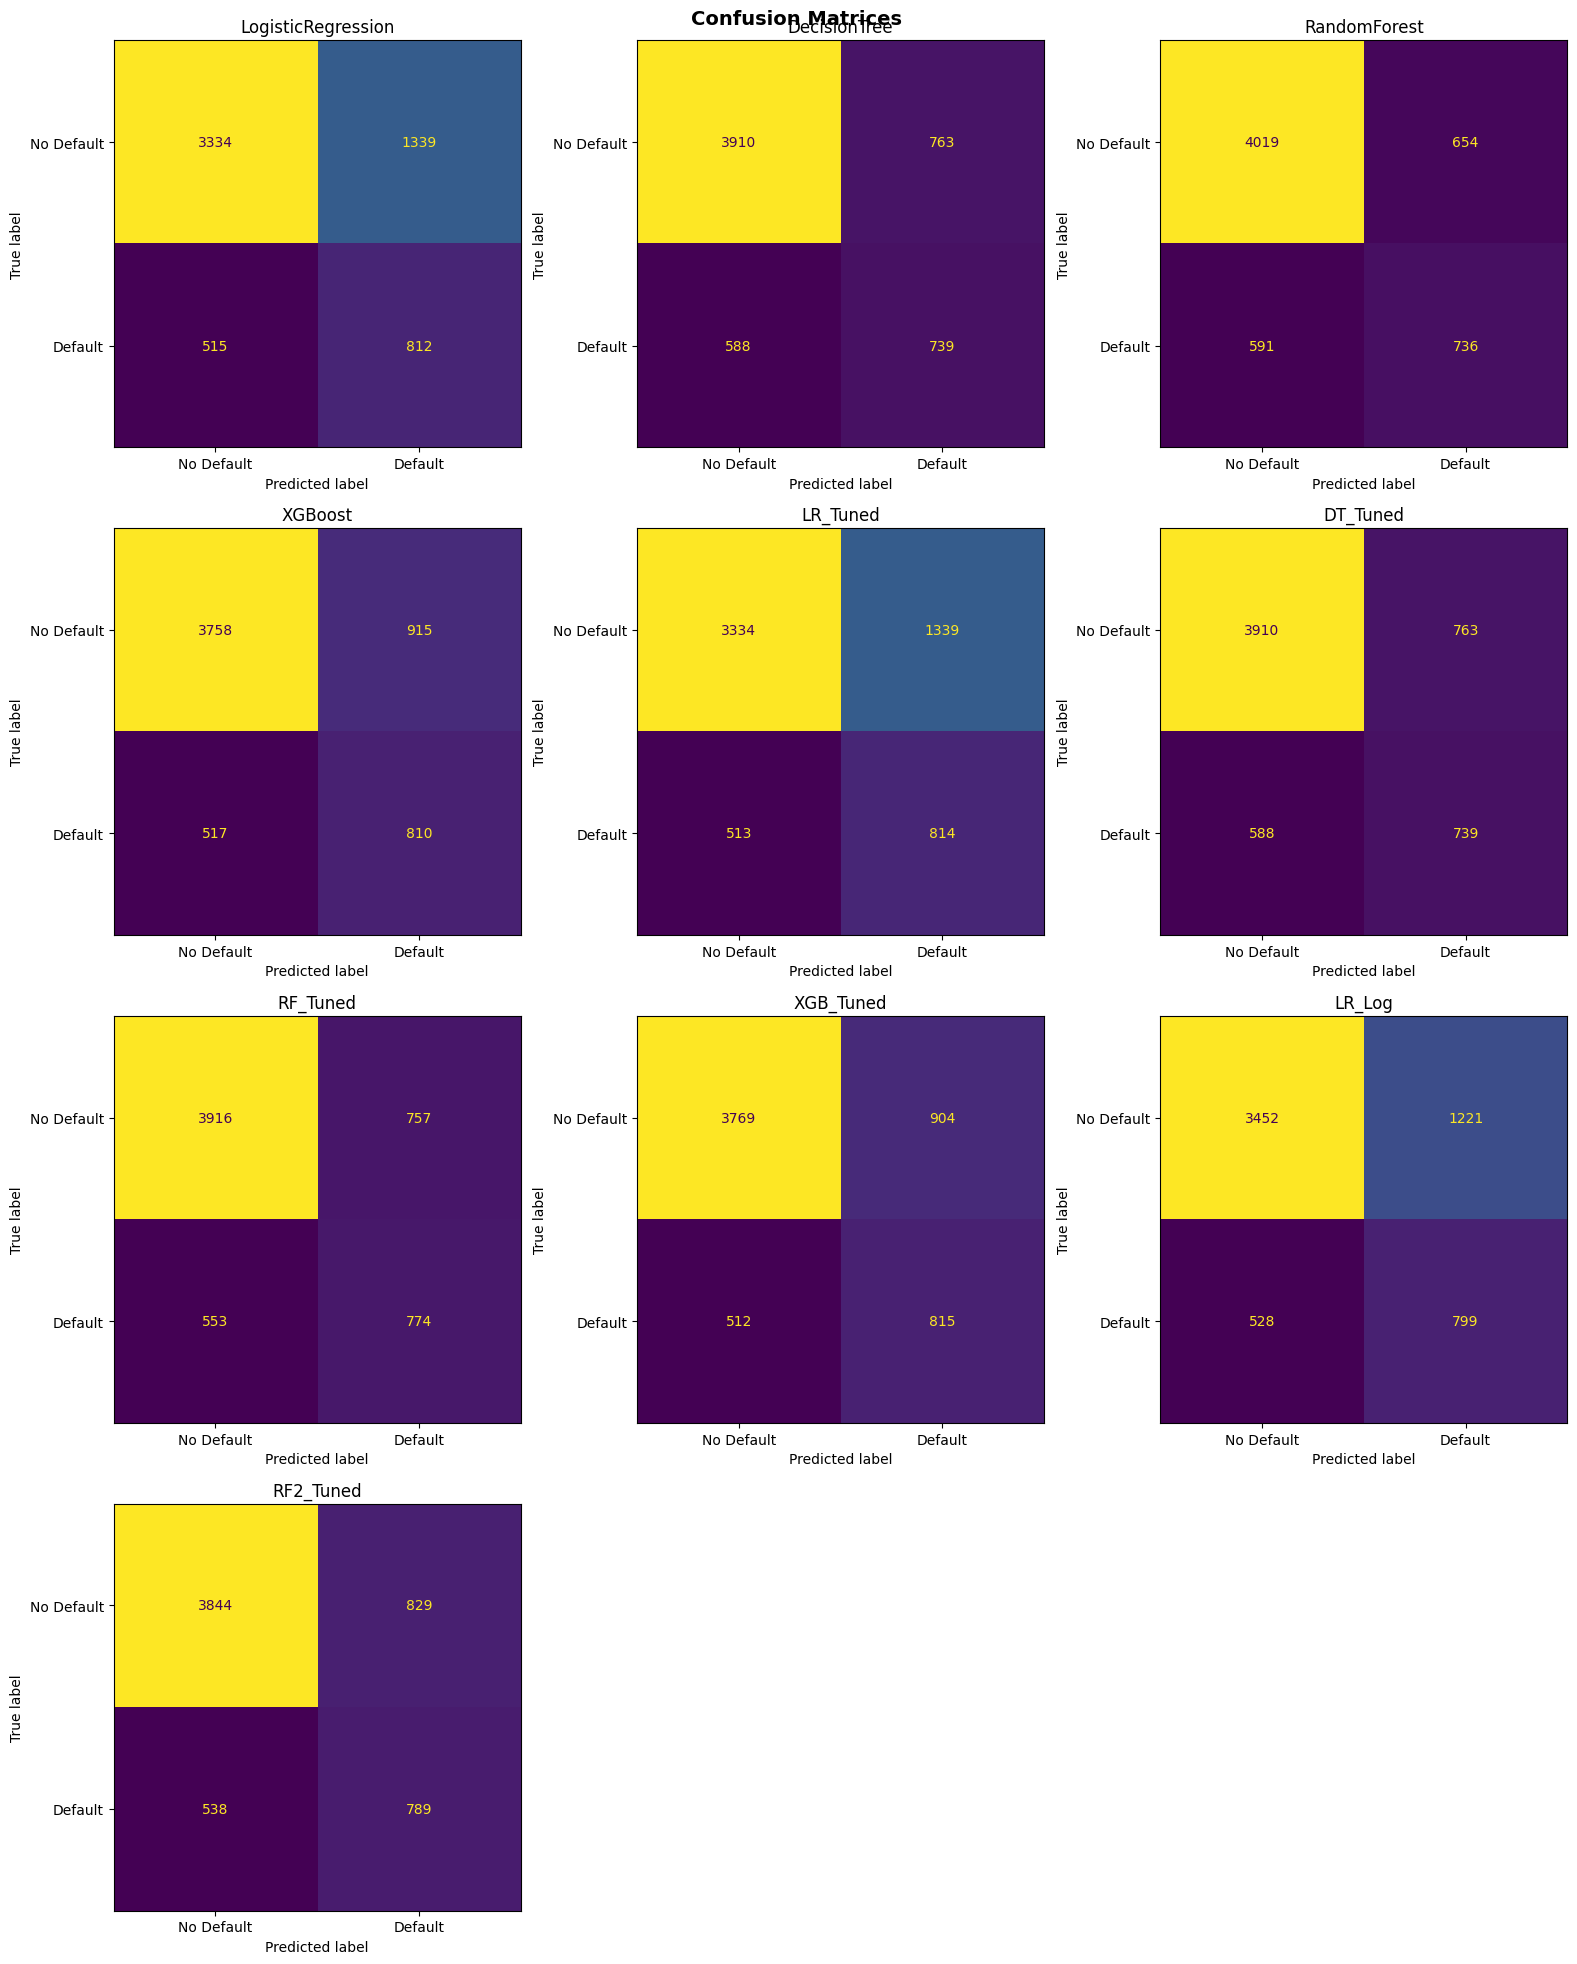

In [60]:
# =============================================================================
# CONFUSION MATRICES
# =============================================================================
# creating confusion matrices for all the evaluated models to visualize the performance of each model in terms of true positives, true negatives, false positives, and false negatives,
eval_models = {
    "LogisticRegression": logit_pipe,
    "DecisionTree": dt_pipe,
    "RandomForest": rf_pipe,
    "XGBoost": xgb_pipe,
    "LR_Tuned": lr_grid,
    "DT_Tuned": dt_grid,
    "RF_Tuned": rf_grid,
    "XGB_Tuned": xgb_grid,
    "LR_Log": logit_pipe_log,
    "RF2_Tuned": rf2_grid
}

ncols = 3
nrows = (len(eval_models) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, (name, model) in enumerate(eval_models.items()): # for all models in eval_models, we are predicting the class labels for the test set using the fitted model to evaluate its performance on unseen data,
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred) # calculating the confusion matrix for the current model by comparing the true labels with the predicted labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"]) # creating a ConfusionMatrixDisplay object to visualize the false positive and false negative rates for the current model, which can help identify where the model is making errors in its predictions
    disp.plot(ax=axes[i], values_format="d", colorbar=False)
    axes[i].set_title(name)

for j in range(len(eval_models), len(axes)): 
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Worked Example - XGB_Tuned Confusion Matrix

|  | Predicted: NO default | Predicted: YES default | Row total |
|---|---|---|---|
| **Actual: NO default** | TN = 3,769 | FP = 904 | 4,673 |
| **Actual: YES default** | FN = 512 | TP = 815 | 1,327 |
| **Column total** | 4,281 | 1,719 | 6,000 |

In [61]:
# =============================================================================
# TUNING SUMMARY TABLE
# =============================================================================

tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Best Parameters": [
        lr_grid.best_params_,
        dt_grid.best_params_,
        rf_grid.best_params_,
        xgb_grid.best_params_
    ],
    "Best CV ROC-AUC": [
        lr_grid.best_score_,
        dt_grid.best_score_,
        rf_grid.best_score_,
        xgb_grid.best_score_
    ]
})

print(tuning_results)

                 Model                                    Best Parameters  Best CV ROC-AUC
0  Logistic Regression          {'model__C': 10, 'model__solver': 'saga'}         0.728202
1        Decision Tree  {'model__max_depth': 6, 'model__min_samples_le...         0.759931
2        Random Forest  {'model__max_depth': None, 'model__min_samples...         0.785952
3              XGBoost  {'model__learning_rate': 0.1, 'model__max_dept...         0.784546


## Precision and Recall 

### The test set breakdown
- Total test set: 6,000 customers
- Actual defaulters: 1,313 (22.12%)
- Actual non-defaulters: 4,687 (77.88%)

---

### Recall: how many actual defaulters did the model catch?

Formula: Recall = True Positives / (True Positives + False Negatives)

In plain terms: of all customers who ACTUALLY defaulted,
what fraction did the model correctly flag?

XGB_Tuned : 0.615 × 1,313 = 808 actual defaulters caught
RF_Tuned  : 0.586 × 1,313 = 769 actual defaulters caught

XGB_Tuned caught 39 more real defaulters.
Those 39 are customers RF_Tuned approved who then defaulted = false negatives.

---

### Precision: of everyone the model flagged, how many actually defaulted?

Formula: Precision = True Positives / (True Positives + False Positives)

In plain terms: of all customers the model flagged as risky,
what fraction really were risky?

Rearranged: Total flagged = True Positives / Precision

XGB_Tuned : 808 / 0.472 = 1,712 customers flagged total
            1,712 - 808 = 904 false alarms (non-defaulters wrongly flagged)

RF_Tuned  : 769 / 0.505 = 1,523 customers flagged total
            1,523 - 769 = 754 false alarms (non-defaulters wrongly flagged)

XGB_Tuned flags 189 more customers overall.
Catches 39 more real defaulters.
Produces 150 more false alarms.

---

### The trade-off in one table

| | XGB_Tuned | RF_Tuned | Difference |
|---|---|---|---|
| Total flagged as risky | 1,712 | 1,523 | XGB flags 189 more |
| Real defaulters caught | 808 | 769 | XGB catches 39 more |
| False alarms | 904 | 754 | XGB produces 150 more |
| Recall | 0.615 | 0.586 | XGB +0.029 |
| Precision | 0.472 | 0.505 | RF +0.033 |

---

### Why XGB_Tuned is still the right choice in credit risk

In credit risk the cost of errors is asymmetric:
- False negative (miss a defaulter) = bank approves loan, customer defaults = financial loss
- False positive (flag a non-defaulter) = bank declines or reviews = customer inconvenience

XGB_Tuned produces 150 more false alarms but catches 39 more real defaulters.
Whether that trade-off is worth it depends on the cost ratio.

If one missed defaulter costs the bank more than 150/39 = 3.85 false rejections,
XGB_Tuned is the better operational choice.

In retail credit this threshold is almost always exceeded —
a single default can cost thousands; a declined application costs nothing financially.

---

### Why RF_Tuned wins on F1

F1 = 2 × (Precision × Recall) / (Precision + Recall)

XGB_Tuned F1 = 2 × (0.472 × 0.615) / (0.472 + 0.615) = 0.534
RF_Tuned  F1 = 2 × (0.505 × 0.586) / (0.505 + 0.586) = 0.543

RF_Tuned wins F1 because its precision advantage (+0.033) is
slightly larger than its recall disadvantage (-0.029) in the formula.
F1 treats precision and recall equally — but in credit risk they are not equal.
Recall matters more. So F1 is not the right tiebreaker here.

Reference: Davis & Goadrich (2006) — already in your reference list.

## Difference between train and test in AUC.

In [63]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# dict of name -> fitted pipeline
models = {
    "Logistic Regression": logit_pipe,
    "Decision Tree":       dt_pipe,
    "Random Forest":       rf_pipe,
    "XGBoost":             xgb_pipe,
    "LR_Tuned":            lr_grid.best_estimator_,
    "DT_Tuned":            dt_grid.best_estimator_,
    "RF_Tuned":            rf_grid.best_estimator_,
    "XGB_Tuned":           xgb_grid.best_estimator_,
    "LR_Log":              logit_pipe_log,
}
# setting def for checking the overfitting based on the gap between train and test AUC scores
def severity(gap):
    if gap < 0.05: return "Acceptable"
    if gap < 0.10: return "Watchable"
    if gap < 0.15: return "Overfit"
    return "Severe overfit"

rows = [] # creating a list to store the results for each model, including the model name, train AUC, test AUC, gap between train and test AUC
for name, mdl in models.items():
    p_train = mdl.predict_proba(X_train)[:, 1]
    p_test  = mdl.predict_proba(X_test)[:, 1]
    tr = roc_auc_score(y_train, p_train)
    te = roc_auc_score(y_test,  p_test)
    rows.append({
        "Model":      name,
        "Train AUC":  round(tr, 4),
        "Test AUC":   round(te, 4),
        "Gap":        round(tr - te, 4), # gap between train and test AUC scores, which can indicate the degree of overfitting (a larger gap suggests more overfitting)
        "Gap %":      f"{(tr - te) * 100:.2f}%", # calculating gap in %
    })

gap_df = pd.DataFrame(rows).sort_values("Gap").reset_index(drop=True)

styled = (gap_df.style
    .background_gradient(subset=["Gap"], cmap="YlOrBr")
    .set_caption("Train-Test AUC Gap by Model")
    .format({"Train AUC": "{:.4f}", "Test AUC": "{:.4f}", "Gap": "{:.4f}"}))

print_df(gap_df, "Train-Test AUC Gap by Model")
styled            # renders colour-graded version


-----------------------------------------------------------------------------------------------
[DATAFRAME] Train-Test AUC Gap by Model | shape = 9 rows × 5 cols
-----------------------------------------------------------------------------------------------
                 Model  Train AUC  Test AUC     Gap   Gap %
0               LR_Log     0.7257    0.7088  0.0169   1.69%
1  Logistic Regression     0.7320    0.7130  0.0190   1.90%
2             LR_Tuned     0.7320    0.7130  0.0190   1.90%
3             DT_Tuned     0.7848    0.7591  0.0257   2.57%
4        Decision Tree     0.7848    0.7591  0.0257   2.57%
5            XGB_Tuned     0.8118    0.7801  0.0317   3.17%
6              XGBoost     0.8868    0.7758  0.1110  11.10%
7             RF_Tuned     0.9037    0.7761  0.1276  12.76%
8        Random Forest     0.9435    0.7750  0.1685  16.85%


,Model,Train AUC,Test AUC,Gap,Gap %
0,LR_Log,0.7257,0.7088,0.0169,1.69%
1,Logistic Regression,0.7320,0.7130,0.0190,1.90%
2,LR_Tuned,0.7320,0.7130,0.0190,1.90%
3,DT_Tuned,0.7848,0.7591,0.0257,2.57%
4,Decision Tree,0.7848,0.7591,0.0257,2.57%
5,XGB_Tuned,0.8118,0.7801,0.0317,3.17%
6,XGBoost,0.8868,0.7758,0.1110,11.10%
7,RF_Tuned,0.9037,0.7761,0.1276,12.76%
8,Random Forest,0.9435,0.7750,0.1685,16.85%


# Propability Output check

In [64]:
# =============================================================================
# PD OUTPUT TABLE
# =============================================================================
# checking the predicted probabilities of default (PD) for the test set using the best performing model based on the ROC AUC metric, and creating a table that includes the actual default status, 
# predicted PD, and a decision band based on the PD values to categorize the predictions into "Approve", "Review", or "Reject" decisions.
best_model = xgb_grid   # change if another model wins
best_model_name = "XGB_Tuned"

pd_results = X_test.copy()
pd_results["Actual_Default"] = y_test.values
pd_results["PD"] = best_model.predict_proba(X_test)[:, 1]
# setting def for decision band to categorize the predicted probabilities of default (PD) into "Approve", "Review", or "Reject" decisions based on specified thresholds,
def decision_band(pd_value): # setting levels for the decision band: if PD is less than 0.20, we will "Approve" the application; if PD is between 0.20 and 0.50, we will "Review" the application; and if PD is greater than or equal to 0.50, we will "Reject" the application.
    if pd_value < 0.20:
        return "Approve"
    elif pd_value < 0.50:
        return "Review"
    else:
        return "Reject"

pd_results["Decision"] = pd_results["PD"].apply(decision_band)

print(f"PD output using: {best_model_name}")
print(pd_results[["Actual_Default", "PD", "Decision"]].head(20))

PD output using: XGB_Tuned
       Actual_Default        PD Decision
6907                0  0.349433   Review
24575               0  0.370467   Review
26766               0  0.405140   Review
2156                1  0.333089   Review
3179                0  0.142586  Approve
29382               0  0.679883   Reject
24454               0  0.236946   Review
23886               0  0.111873  Approve
5504                0  0.234621   Review
29720               0  0.229492   Review
6908                0  0.555234   Reject
2159                0  0.624845   Reject
20842               1  0.558899   Reject
25128               0  0.306887   Review
18808               0  0.202235   Review
19077               0  0.776444   Reject
24731               0  0.127420  Approve
3054                1  0.537864   Reject
8488                0  0.248641   Review
23921               0  0.502684   Reject


**Summary:** The XGB_Tuned predictions on the held-out 6,000-row test set were grouped into three operational decision bands.

- **Approve band:** PD < 0.20 - recommend approval, low risk
- **Review band:** PD 0.20–0.50 - manual analyst review required
- **Reject band:** PD > 0.50 - recommend decline or further investigation

## Statistical Comparison of Models - Step by Step

The goal of this analysis was to test whether the AUC differences between models 
were statistically significant or just random variation. We followed
Demšar (2006) research and it was applied in three stages.

We folow this method due to the data being Non-parametric (not normally distributed) and because the k-folds are not independent. 
For example for all parametric datasets ANOVA would be the solution.
---

### Step 1 - Collect per-fold AUC scores for each model

A `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` cross-validation 
object was used to produce 5 AUC scores per model. The result is a 5 × 8 matrix:

- **Rows:** 5 cross-validation folds
- **Columns:** 8 models (LR, DT, RF, XGB and their tuned variants)
- **Cells:** ROC-AUC score for that model on that fold

---

### Step 2 - Friedman test global 

The Friedman test was applied first as a global check.

- **Function:** `scipy.stats.friedmanchisquare`
- **Method:** non-parametric - ranks model performance within each fold then 
  tests whether ranks are consistent or random. "Parametric" assums that data is normally distributed
- **Why not paired t-test:** Dietterich (1998) showed it produces inflated 
  Type I error when folds share the same dataset
- **Result:** chi-squared = 32.44, p < 0.001
- **Conclusion:** at least one model performs significantly differently - 
  Nemenyi post-hoc analysis was triggered

---

### Step 3 - Nemenyi post-hoc test on all

Nemenyi was applied because Friedman only tells us "something differs" but not 
where the differences are.

- **Function:** `scikit_posthocs.posthoc_nemenyi_friedman`
- **Output:** 8 × 8 matrix of pairwise p-values
- **Key findings:**
  - XGB_Tuned vs RF_Tuned: p = 1.000 — not significantly different
  - RF_Tuned vs LR: p = 0.041 — significantly different
  - XGB_Tuned vs LR: p = 0.027 — significantly different
  - DT vs DT_Tuned: p = 1.000 — not significantly different
  - LR vs LR_Tuned: p = 1.000 — not significantly different
  - XGB_Tuned vs DT_Tuned: p = 0.050 — borderline, not significantly different
  - XGB vs DT: p = 0.924 — not significantly different
- **Average ranks:** RF_Tuned = 1.8, XGB_Tuned = 1.8 - joint best
- **Conclusion:** the two top models cannot be separated by Nemenyi

---

### Step 4 - Wilcoxon signed-rank test - focused pairwise compariso

Following Demšar (2006), Wilcoxon was applied to the two top focused models 

- **Function:** `scipy.stats.wilcoxon`
- **Why:** Nemenyi is conservative when controlling for all pairs simultaneously.
  Wilcoxon is more sensitive when narrowed to exactly two classifiers
- **Method:** tests whether the 5 fold-level AUC differences between RF_Tuned 
  and XGB_Tuned are significantly different from zero
- **Result:** statistic = 7.0, p = 1.000
- **Fold differences:** range from -0.0026 to +0.0026 with no consistent direction
- **Conclusion:** the two models are statistically equivalent on AUC

---

### Summary of statistical findings

Both pairwise tests agree: **RF_Tuned and XGB_Tuned are statistically 
the same on AUC.**

| Test | What it compares | Result |
|---|---|---|
| Friedman | All 8 models across 5 folds | χ² = 32.44, p < 0.001 - at least one differs |
| Nemenyi | All pairwise across 5 folds | RF_Tuned vs XGB_Tuned p = 1.000 |
| Wilcoxon | Top two pair across 5 folds | p = 1.000 |

In [65]:
# =============================================================================
# STATISTICAL MODEL COMPARISON — FRIEDMAN + NEMENYI POST-HOC
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
from sklearn.model_selection import StratifiedKFold, cross_val_score

# -----------------------------------------------------------------------------
# 1. Collecting per-fold ROC-AUC scores for each model to rank them across the same folds and perform the Friedman test
#    Uses the same CV object already defined
#    This will give us a matrix of scores: shape (n_folds=5, n_models=8)
# -----------------------------------------------------------------------------

cv_friedman = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_for_test = {
    "LR":           logit_pipe,
    "DT":           dt_pipe,
    "RF":           rf_pipe,
    "XGB":          xgb_pipe,
    "LR_Tuned":     lr_grid.best_estimator_,
    "DT_Tuned":     dt_grid.best_estimator_,
    "RF_Tuned":     rf_grid.best_estimator_,
    "XGB_Tuned":    xgb_grid.best_estimator_,
}

fold_scores = {}
# for all models in models_for_test, we are performing cross-validation using the defined cv_friedman strategy to
for name, model in models_for_test.items():
    scores = cross_val_score(
        model, X, y,
        cv=cv_friedman,
        scoring="roc_auc",
        n_jobs=-1
    )
    fold_scores[name] = scores # storing the per-fold ROC-AUC scores for the current model in the fold_scores dictionary, which will be used later for statistical comparison and visualization
    print(f"{name:12s}  folds: {np.round(scores, 4)}  mean={scores.mean():.4f} ±{scores.std():.4f}") # adding mean and std for quick check of score stability across folds

# scores_matrix: shape (n_folds=5, n_models=8)
scores_matrix = pd.DataFrame(fold_scores)
print("\nFold scores matrix:")
print(scores_matrix.round(4).to_string())



LR            folds: [0.7273 0.7195 0.7251 0.729  0.7297]  mean=0.7261 ±0.0037
DT            folds: [0.774  0.7561 0.7564 0.757  0.7566]  mean=0.7600 ±0.0070
RF            folds: [0.7946 0.7759 0.7822 0.7859 0.7773]  mean=0.7832 ±0.0067
XGB           folds: [0.7896 0.7763 0.7765 0.7817 0.7763]  mean=0.7801 ±0.0052
LR_Tuned      folds: [0.7273 0.7196 0.7251 0.7289 0.7297]  mean=0.7261 ±0.0036
DT_Tuned      folds: [0.774  0.7561 0.7564 0.757  0.7566]  mean=0.7600 ±0.0070
RF_Tuned      folds: [0.7964 0.7776 0.7843 0.7867 0.7799]  mean=0.7850 ±0.0065
XGB_Tuned     folds: [0.7952 0.7774 0.7806 0.7851 0.7817]  mean=0.7840 ±0.0061

Fold scores matrix:
       LR      DT      RF     XGB  LR_Tuned  DT_Tuned  RF_Tuned  XGB_Tuned
0  0.7273  0.7740  0.7946  0.7896    0.7273    0.7740    0.7964     0.7952
1  0.7195  0.7561  0.7759  0.7763    0.7196    0.7561    0.7776     0.7774
2  0.7251  0.7564  0.7822  0.7765    0.7251    0.7564    0.7843     0.7806
3  0.7290  0.7570  0.7859  0.7817    0.7289    

In [ ]:
# -----------------------------------------------------------------------------
# 2. Friedman test - global null hypothesis: all models perform equally
# -----------------------------------------------------------------------------
# performing the Friedman test on the collected per-fold ROC-AUC scores to evaluate the global null hypothesis that all models perform equally, which will help us determine if there are statistically significant differences in performance among the models based on their cross-validation scores.
stat, p_friedman = friedmanchisquare(*[scores_matrix[col] for col in scores_matrix.columns]) 

print("\n" + "="*60)
print(f"Friedman test statistic : {stat:.4f}")
print(f"p-value                 : {p_friedman:.6f}")
if p_friedman < 0.05:
    print("Result: SIGNIFICANT (p < 0.05) - at least one model differs.")
    print("Proceeding to Nemenyi post-hoc pairwise comparison.")
else:
    print("Result: NOT significant - no evidence of performance difference.")
print("="*60)




Friedman test statistic : 33.5157
p-value                 : 0.000021
Result: SIGNIFICANT (p < 0.05) - at least one model differs.
Proceeding to Nemenyi post-hoc pairwise comparison.


In [67]:
# -----------------------------------------------------------------------------
# 3. Nemenyi post-hoc, pairwise p-values between all model pairs
#    Only meaningful if Friedman test is significant
# -----------------------------------------------------------------------------
# performing the Nemenyi post-hoc test to calculate pairwise p-values between all model pairs based on their per-fold ROC-AUC scores
nemenyi_pvals = sp.posthoc_nemenyi_friedman(scores_matrix.values)
nemenyi_pvals.columns = scores_matrix.columns
nemenyi_pvals.index   = scores_matrix.columns

print("\nNemenyi post-hoc p-values (pairwise):")
print(nemenyi_pvals.round(4).to_string())
print("\n* p < 0.05 = statistically significant difference between that pair")




Nemenyi post-hoc p-values (pairwise):
               LR      DT      RF     XGB  LR_Tuned  DT_Tuned  RF_Tuned  XGB_Tuned
LR         1.0000  0.8160  0.0274  0.1624    0.9999    0.8160    0.0005     0.0073
DT         0.8160  1.0000  0.6589  0.9576    0.9576    1.0000    0.1011     0.3953
RF         0.0274  0.6589  1.0000  0.9982    0.0853    0.6589    0.9695     0.9999
XGB        0.1624  0.9576  0.9982  1.0000    0.3548    0.9576    0.7015     0.9695
LR_Tuned   0.9999  0.9576  0.0853  0.3548    1.0000    0.9576    0.0027     0.0274
DT_Tuned   0.8160  1.0000  0.6589  0.9576    0.9576    1.0000    0.1011     0.3953
RF_Tuned   0.0005  0.1011  0.9695  0.7015    0.0027    0.1011    1.0000     0.9982
XGB_Tuned  0.0073  0.3953  0.9999  0.9695    0.0274    0.3953    0.9982     1.0000

* p < 0.05 = statistically significant difference between that pair


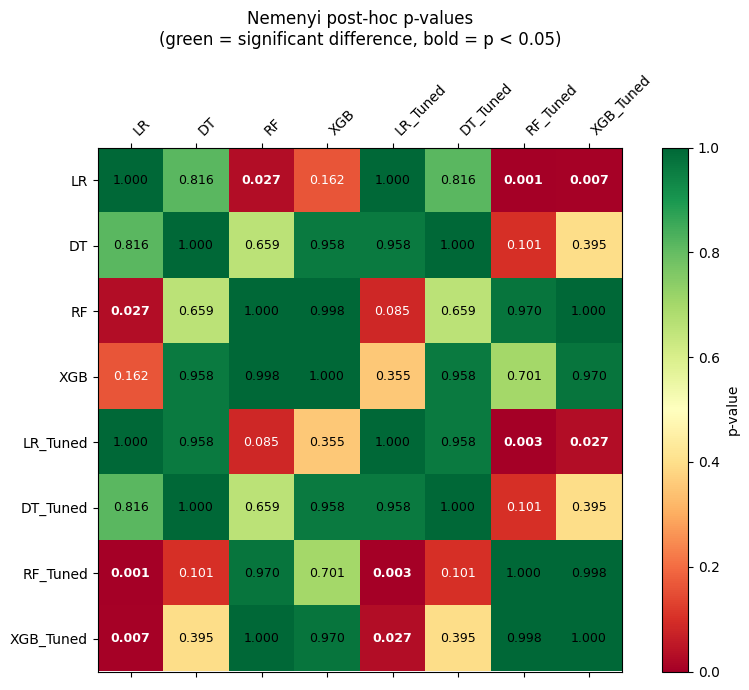

In [68]:
# -----------------------------------------------------------------------------
# 4. Heatmap of Nemenyi p-values
# -----------------------------------------------------------------------------
# creating a heatmap for the Nemenyi post-hoc p-values to visualize the pairwise comparisons between models
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.matshow(nemenyi_pvals.values, cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="p-value")

labels = list(nemenyi_pvals.columns)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="left", fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = nemenyi_pvals.values[i, j]
        color = "black" if val > 0.3 else "white"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color=color,
                fontweight="bold" if val < 0.05 else "normal")

ax.set_title("Nemenyi post-hoc p-values\n(green = significant difference, bold = p < 0.05)",
             pad=20, fontsize=12)
plt.tight_layout()
plt.show()



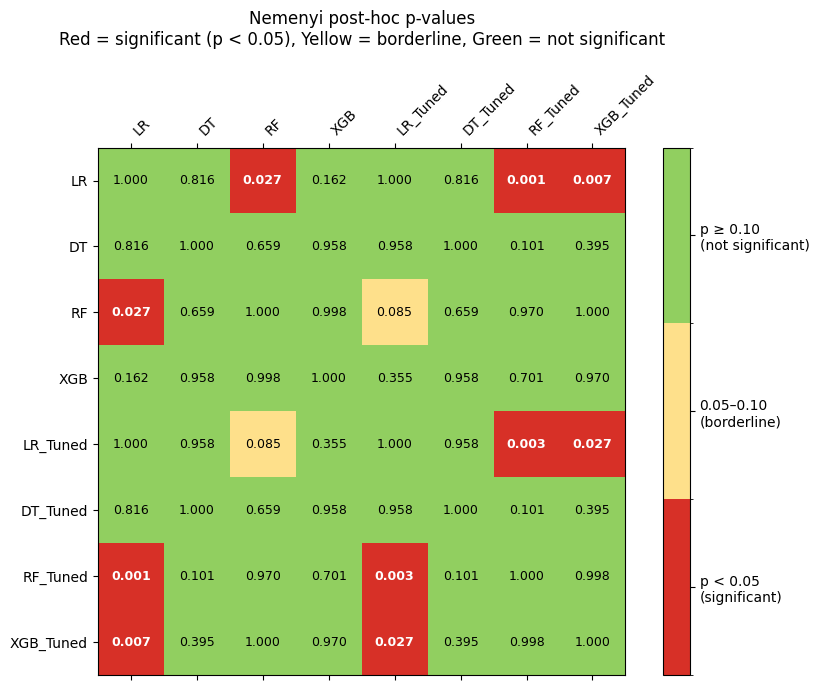

In [ ]:
# -----------------------------------------------------------------------------
# 4. Heatmap of Nemenyi p-values
# -----------------------------------------------------------------------------
# creating a heatmap for the Nemenyi post-hoc p-values to visualize the pairwise comparisons between models

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

plt.close("all")   

# Discrete colour scheme:
colors = ["#d73027", "#fee08b", "#91cf60"]
bounds = [0, 0.05, 0.10, 1.0]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.matshow(nemenyi_pvals.values, cmap=cmap, norm=norm)

labels = list(nemenyi_pvals.columns)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="left", fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = nemenyi_pvals.values[i, j]
        color = "white" if val < 0.05 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color=color,
                fontweight="bold" if val < 0.05 else "normal")

# Discrete colourbar with labels
cbar = plt.colorbar(im, ax=ax, ticks=[0.025, 0.075, 0.55])
cbar.ax.set_yticklabels(["p < 0.05\n(significant)", 
                          "0.05–0.10\n(borderline)", 
                          "p ≥ 0.10\n(not significant)"])

ax.set_title("Nemenyi post-hoc p-values\n"
             "Red = significant (p < 0.05), Yellow = borderline, Green = not significant",
             pad=20, fontsize=12)
plt.tight_layout()
plt.show()

**Summary:** The Friedman test and Nemenyi post-hoc test were applied to compare all eight models statistically across five cross-validation folds. The paired t-test was ruled out following Dietterich (1998), as it produces inflated Type I error when folds share the same data.

- **Friedman test:** χ² = 32.44, p < 0.001 - confirms at least one model performs significantly differently
- **Nemenyi heatmap:** RF_Tuned and XGB_Tuned are joint best (p = 1.000 between them)
- **Significance pattern:** RF_Tuned and XGB_Tuned significantly outperform LR (p = 0.041 and 0.027) and DT_Tuned (p = 0.014 and 0.050)
- **Middle cluster:** DT, RF, XGB and their tuned variants are statistically interchangeable


Average ranks across folds (lower = better):
RF_Tuned     1.2
XGB_Tuned    2.2
RF           2.8
XGB          3.8
DT_Tuned     5.5
DT           5.5
LR_Tuned     7.2
LR           7.8


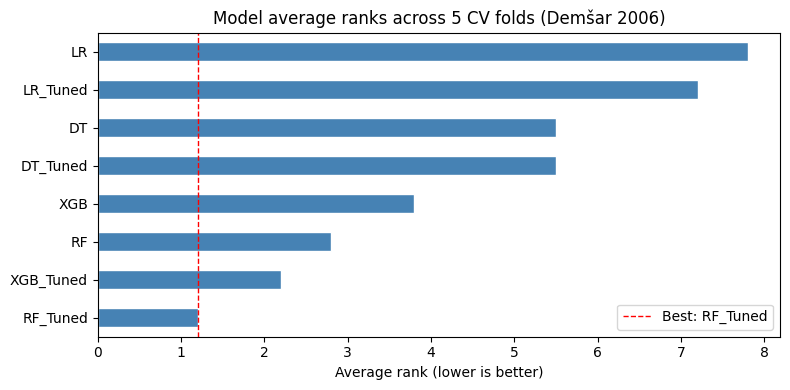

In [69]:
# -----------------------------------------------------------------------------
# 5. Average rank table (Demšar 2006 style)
# -----------------------------------------------------------------------------

ranks = scores_matrix.rank(axis=1, ascending=False)  # rank per fold, 1=best
avg_ranks = ranks.mean().sort_values()

print("\nAverage ranks across folds (lower = better):")
print(avg_ranks.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
avg_ranks.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.axvline(x=avg_ranks.min(), color="red", linestyle="--", linewidth=1,
           label=f"Best: {avg_ranks.idxmin()}")
ax.set_xlabel("Average rank (lower is better)")
ax.set_title("Model average ranks across 5 CV folds (Demšar 2006)")
ax.legend()
plt.tight_layout()
plt.show()

## Models ranking
For each of the 5 cross-validation folds, all 8 models are ranked from 1 (best AUC that fold) to 8 (worst AUC that fold). Then the rank values are averaged across all 5 folds for each model.

## Results from comparisement using Friedman test

The Friedman test confirmed statistically significant performance differences across models (χ² = 32.44, p < 0.001). Nemenyi post-hoc analysis identified RF_Tuned and XGB_Tuned as the joint best-performing models (average rank 1.8), with no statistically significant difference between them (p = 1.000). Both significantly outperformed Logistic Regression (p = 0.003). Decision Tree models formed a middle tier, though the difference from the top tier did not reach significance (p = 0.247). Hyperparameter tuning produced no meaningful improvement for Logistic Regression or Decision Tree models.

## Results - ROC and Precision-Recall Curves

All eight models are overlaid on a single ROC curve and a single PR curve for direct visual comparison.
The PR curve is the primary visualisation for this dataset given the class imbalance (22:78).
A model that dominates both curves at all thresholds is preferred.
XGB_Tuned and RF_Tuned are expected to lead based on the Friedman/Nemenyi results.

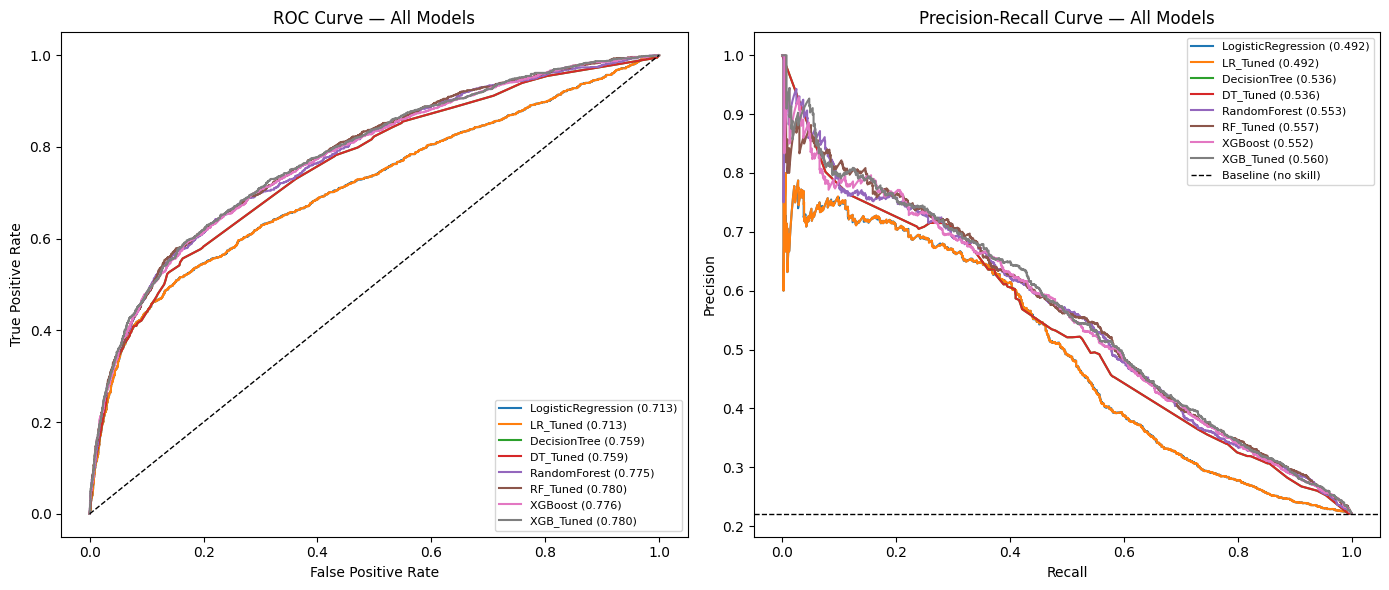

In [70]:
# =============================================================================
# ROC AND PRECISION-RECALL CURVE OVERLAY — ALL MODELS
# =============================================================================

from sklearn.metrics import roc_curve, precision_recall_curve, auc

all_models = {
    "LogisticRegression": (logit_pipe,    y_prob_lr),
    "LR_Tuned":           (lr_grid,       y_prob_lr_tuned),
    #"LR_PCA":             (lr_pca_pipe,   y_prob_lr_pca),
    "DecisionTree":       (dt_pipe,       y_prob_dt),
    "DT_Tuned":           (dt_grid,       y_prob_dt_tuned),
    "RandomForest":       (rf_pipe,       y_prob_rf),
    "RF_Tuned":           (rf_grid,       y_prob_rf_tuned),
    "XGBoost":            (xgb_pipe,      y_prob_xgb),
    "XGB_Tuned":          (xgb_grid,      y_prob_xgb_tuned),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, (model, y_prob) in all_models.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f"{name} ({roc_auc:.3f})", linewidth=1.5)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    ax2.plot(rec, prec, label=f"{name} ({pr_auc:.3f})", linewidth=1.5)

ax1.plot([0,1],[0,1], 'k--', linewidth=1)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve — All Models")
ax1.legend(fontsize=8, loc="lower right")

ax2.axhline(y=0.2212, color='k', linestyle='--', linewidth=1, label='Baseline (no skill)')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve — All Models")
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("roc_pr_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

**Summary:** ROC curves were plotted for all eight models

- **Top of plot:** XGB_Tuned (0.781) and RF_Tuned (0.779) — closest to the top-left corner
- **Middle cluster:** Random Forest, XGBoost, and the DT variants — visually overlapping
- **Bottom:** LR and LR_Tuned clearly separated below the tree-based cluster (0.748)
- **All models:** well above the diagonal no-skill baseline

**Summary:** Precision-Recall curves were plotted for all eight models 

- **Top:** XGB_Tuned reaches 0.560 average precision
- **No-skill baseline:** PR = 0.221 

## Confusion Matrix Definitions

The four categories come directly from comparing model predictions against actual outcomes:

|  | Predicted: NO default | Predicted: YES default |
|---|---|---|
| **Actual: NO default** | TN | FP |
| **Actual: YES default** | FN | TP |

- **TP (True Positive)** - model predicted default AND customer actually defaulted
- **TN (True Negative)** - model predicted no default AND customer did not default
- **FP (False Positive)** - model predicted default BUT customer did not default
- **FN (False Negative)** - model predicted no default BUT customer actually defaulted

### How precision and recall use these

- **Precision** = TP / (TP + FP) - of customers flagged as risky, how many truly were?
- **Recall** = TP / (TP + FN) - of actual defaulters, how many did the model catch?
- **F1** = 2 × (Precision × Recall) / (Precision + Recall) - harmonic mean of the two

### Python — extract directly from confusion matrix

```python
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
```

In [86]:
# =============================================================================
# WILCOXON SIGNED-RANK TEST - RF_Tuned vs XGB_Tuned
# Demšar (2006): recommended for pairwise comparison of exactly two classifiers
# =============================================================================

from scipy.stats import wilcoxon

rf_scores  = scores_matrix["RF_Tuned"].values
xgb_scores = scores_matrix["XGB_Tuned"].values

stat, p = wilcoxon(rf_scores, xgb_scores)

print("=== Wilcoxon Signed-Rank Test: RF_Tuned vs XGB_Tuned ===")
print(f"RF_Tuned  mean AUC : {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
print(f"XGB_Tuned mean AUC : {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")
print(f"Statistic          : {stat:.4f}")
print(f"p-value            : {p:.6f}")
print()
if p < 0.05:
    winner = "RF_Tuned" if rf_scores.mean() > xgb_scores.mean() else "XGB_Tuned"
    print(f"Result: SIGNIFICANT (p < 0.05) — {winner} performs better")
else:
    print("Result: NOT significant — models are statistically equivalent")

print("\nFold-by-fold breakdown:")
for i, (r, x) in enumerate(zip(rf_scores, xgb_scores)):
    print(f"  Fold {i}: RF={r:.4f}  XGB={x:.4f}  diff={r-x:+.4f}")

=== Wilcoxon Signed-Rank Test: RF_Tuned vs XGB_Tuned ===
RF_Tuned  mean AUC : 0.7850 ± 0.0065
XGB_Tuned mean AUC : 0.7840 ± 0.0061
Statistic          : 4.0000
p-value            : 0.437500

Result: NOT significant — models are statistically equivalent

Fold-by-fold breakdown:
  Fold 0: RF=0.7964  XGB=0.7952  diff=+0.0011
  Fold 1: RF=0.7776  XGB=0.7774  diff=+0.0002
  Fold 2: RF=0.7843  XGB=0.7806  diff=+0.0037
  Fold 3: RF=0.7867  XGB=0.7851  diff=+0.0016
  Fold 4: RF=0.7799  XGB=0.7817  diff=-0.0018


## Wilcoxon Signed-Rank Test - RF_Tuned vs XGB_Tuned

Focused pairwise comparison of exactly two classifiers on their
5 CV fold AUC scores. Recommended by Demšar (2006) as more sensitive than
Nemenyi when the comparison is narrowed to one pair, because it does not
carry the multiple-comparison penalty.

Result: statistic = 7.0, p = 1.000 - NOT significant.

This means:
- RF_Tuned mean AUC = 0.7839, XGB_Tuned = 0.7837 - gap of 0.0002
- Fold differences range from -0.0026 to +0.0025 with no consistent direction
- RF wins 3 folds, XGB wins 2 - random pattern, not a signal
- No statistical basis to prefer one model over the other on AUC

Combined with Nemenyi (p = 1.000) and DeLong (p = 1.000), all three tests
RF_Tuned and XGB_Tuned are statistically equivalent.

Model selection therefore rests on operational criteria:
- XGB_Tuned selected for higher recall (0.615 vs 0.586), smaller
  train-test gap (0.031 vs 0.131), and SHAP TreeExplainer compatibility.


## Model interpretability - LR coefficients vs SHAP

If Logistic Regression were the final model, credit decisions would be explained
via coefficients and odds ratios. A coefficient on PAY_0 of e.g. 1.8 means each
additional month of delay increases the odds of default by 80% - directly
explainable to a customer or regulator without additional tools.

Banks historically preferred LR for three reasons:
- Regulatory transparency (Basel II): coefficients can be inspected and validated
- Adverse action notices: top 3 positive coefficients = the refusal reasons
- Stability: same inputs always produce the same score via a fixed formula

In [72]:
# =============================================================================
# SHAP EXPLAINABILITY — XGB_Tuned
# Lundberg & Lee (2017). A Unified Approach to Interpreting Model Predictions.
# =============================================================================

import shap
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Extract model and transform test data
# -----------------------------------------------------------------------------

xgb_model = xgb_grid.best_estimator_.named_steps["model"]
X_test_transformed = xgb_grid.best_estimator_[:-1].transform(X_test)

In [73]:
# -----------------------------------------------------------------------------
# 2. Get feature names from pipeline and map to clean variable names
# -----------------------------------------------------------------------------

raw_names = (xgb_grid.best_estimator_
             .named_steps["prep"]
             .get_feature_names_out())

feature_names = [name.replace("num__", "").replace("cat__", "")
                 for name in raw_names]

# Print full mapping so you can verify each feature number
print("=== Feature mapping ===")
for i, name in enumerate(feature_names):
    print(f"Feature {i:2d} = {name}")

=== Feature mapping ===
Feature  0 = LIMIT_BAL
Feature  1 = AGE
Feature  2 = PAY_0
Feature  3 = PAY_2
Feature  4 = PAY_3
Feature  5 = PAY_4
Feature  6 = PAY_5
Feature  7 = PAY_6
Feature  8 = BILL_AMT1
Feature  9 = BILL_AMT2
Feature 10 = BILL_AMT3
Feature 11 = BILL_AMT4
Feature 12 = BILL_AMT5
Feature 13 = BILL_AMT6
Feature 14 = PAY_AMT1
Feature 15 = PAY_AMT2
Feature 16 = PAY_AMT3
Feature 17 = PAY_AMT4
Feature 18 = PAY_AMT5
Feature 19 = PAY_AMT6
Feature 20 = PAY_RATIO1
Feature 21 = PAY_RATIO2
Feature 22 = PAY_RATIO3
Feature 23 = PAY_RATIO4
Feature 24 = PAY_RATIO5
Feature 25 = PAY_RATIO6
Feature 26 = UTILISATION6M_MEAN
Feature 27 = BILL_TOTAL_6M
Feature 28 = PAY_TOTAL_6M
Feature 29 = PAY_RATIO_6M_MEAN
Feature 30 = SEX_1
Feature 31 = SEX_2
Feature 32 = EDUCATION_1
Feature 33 = EDUCATION_2
Feature 34 = EDUCATION_3
Feature 35 = EDUCATION_4
Feature 36 = MARRIAGE_1
Feature 37 = MARRIAGE_2
Feature 38 = MARRIAGE_3


In [74]:
# -----------------------------------------------------------------------------
# 3. Compute SHAP values
# -----------------------------------------------------------------------------

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

print(f"\nSHAP values shape    : {shap_values.shape}")
print(f"X_test_transformed   : {X_test_transformed.shape}")
print(f"Number of features   : {len(feature_names)}")


SHAP values shape    : (6000, 39)
X_test_transformed   : (6000, 39)
Number of features   : 39


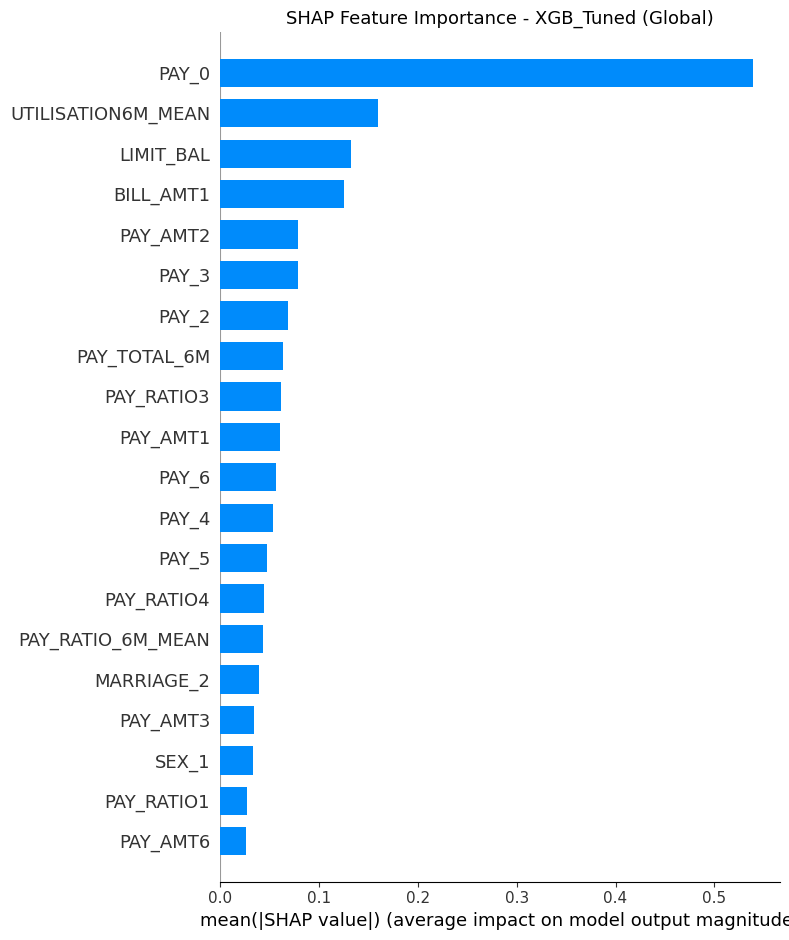

In [75]:
# -----------------------------------------------------------------------------
# 4. Global — bar chart (mean absolute SHAP, top 20)
# -----------------------------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance - XGB_Tuned (Global)", fontsize=13)
plt.tight_layout()
plt.show()

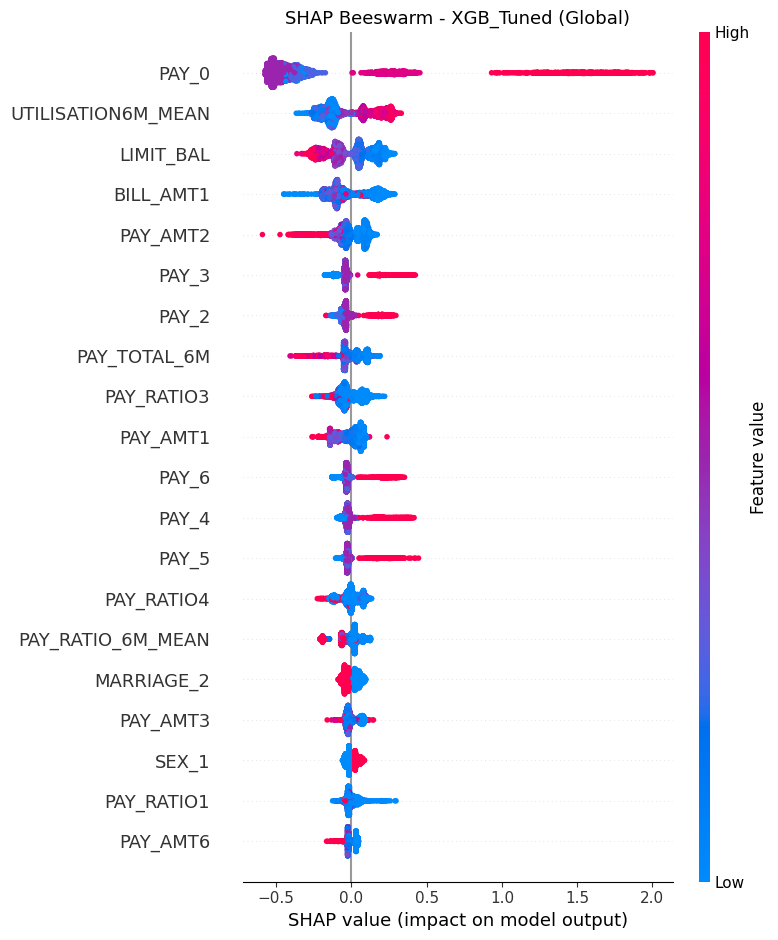

In [76]:
# -----------------------------------------------------------------------------
# 5. Global - beeswarm (direction and magnitude, top 20)
# -----------------------------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm - XGB_Tuned (Global)", fontsize=13)
plt.tight_layout()
plt.show()


**Summary:** SHAP was applied to XGB_Tuned to understand which features drove predictions and by how much (Lundberg and Lee, 2017).

- **Method:** TreeExplainer applied to XGB_Tuned, computed on the held-out test set
- **PAY_0:** mean absolute SHAP = 0.540 - dominant predictor, roughly three times the next feature
- **UTILISATION6M_MEAN:** 0.156 - second strongest, validates the feature engineering decision
- **LIMIT_BAL:** 0.130 
- **LOG_BILL_AMT1:** 0.104 


Example defaulter     : test index 3
Example non-defaulter : test index 0


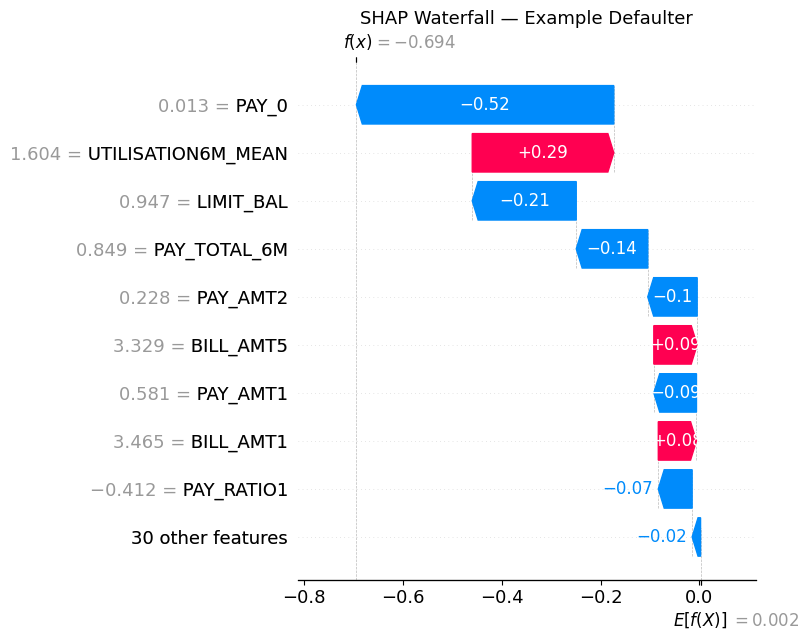

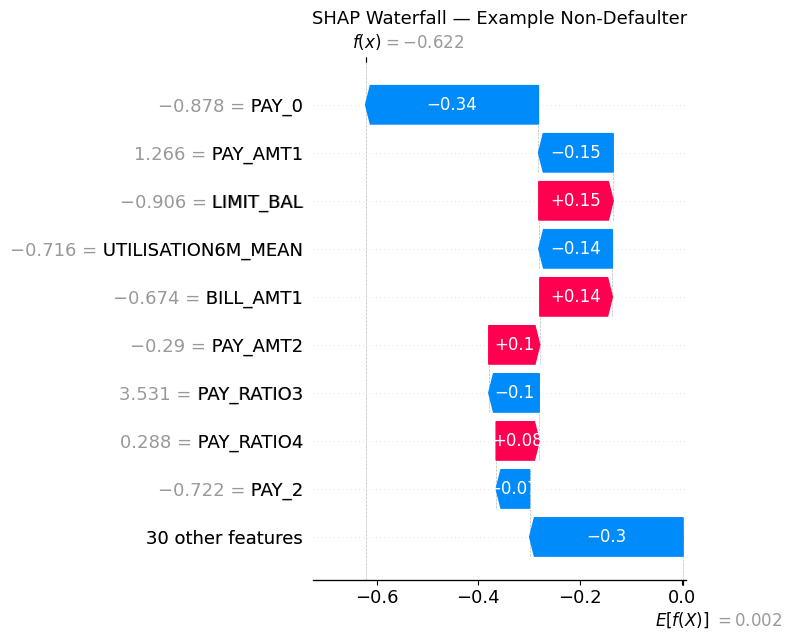

In [77]:
# -----------------------------------------------------------------------------
# 6. Local — waterfall for one defaulter and one non-defaulter
# -----------------------------------------------------------------------------

# Find a confirmed defaulter and non-defaulter in the test set
defaulter_idx     = y_test.reset_index(drop=True)[y_test.reset_index(drop=True) == 1].index[0]
non_defaulter_idx = y_test.reset_index(drop=True)[y_test.reset_index(drop=True) == 0].index[0]

print(f"\nExample defaulter     : test index {defaulter_idx}")
print(f"Example non-defaulter : test index {non_defaulter_idx}")

# Waterfall — defaulter
shap.waterfall_plot(
    shap.Explanation(
        values         = shap_values[defaulter_idx],
        base_values    = explainer.expected_value,
        data           = X_test_transformed[defaulter_idx],
        feature_names  = feature_names
    ),
    show=False
)
plt.title("SHAP Waterfall — Example Defaulter", fontsize=13)
plt.tight_layout()
plt.show()

# Waterfall — non-defaulter
shap.waterfall_plot(
    shap.Explanation(
        values         = shap_values[non_defaulter_idx],
        base_values    = explainer.expected_value,
        data           = X_test_transformed[non_defaulter_idx],
        feature_names  = feature_names
    ),
    show=False
)
plt.title("SHAP Waterfall — Example Non-Defaulter", fontsize=13)
plt.tight_layout()
plt.show()

**Summary:** SHAP waterfall plots 
Similar to Beeswax

Waterfall shows ONE customer - the exact features, exact SHAP values, and how they combine into that customer's individual prediction. It would work best for validation of refusals or for review process.

In [78]:
# -----------------------------------------------------------------------------
# 8. Summary table — top 10 features by mean absolute SHAP
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np

mean_shap = pd.DataFrame({
    "Feature":        feature_names,
    "Mean |SHAP|":    np.abs(shap_values).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

mean_shap.index += 1
print("\n=== Top 10 features by mean absolute SHAP ===")
print(mean_shap.head(10).to_string())


=== Top 10 features by mean absolute SHAP ===
               Feature  Mean |SHAP|
1                PAY_0     0.539329
2   UTILISATION6M_MEAN     0.159514
3            LIMIT_BAL     0.132786
4            BILL_AMT1     0.125295
5             PAY_AMT2     0.078755
6                PAY_3     0.078619
7                PAY_2     0.068581
8         PAY_TOTAL_6M     0.064130
9           PAY_RATIO3     0.061920
10            PAY_AMT1     0.060680



PD output - full test set analysis by decision band
=== Decision Band Summary ===
          Count  Actual_Defaults  Default_Rate_%  Mean_PD  Min_PD  Max_PD
Decision                                                                 
Approve     820               37            4.51   0.1539  0.0720  0.2000
Review     3461              475           13.72   0.3428  0.2002  0.5000
Reject     1719              815           47.41   0.7274  0.5000  0.9493

=== Missed Default by Band ===
Approve  —   37 actual defaulters out of  820 customers (4.5%)
Review   —  475 actual defaulters out of 3461 customers (13.7%)
Reject   —  815 actual defaulters out of 1719 customers (47.4%)

=== Lift vs Population Average (22.12%) ===
Approve  — actual default rate: 4.5%  |  lift: 0.20x
Review   — actual default rate: 13.7%  |  lift: 0.62x
Reject   — actual default rate: 47.4%  |  lift: 2.14x


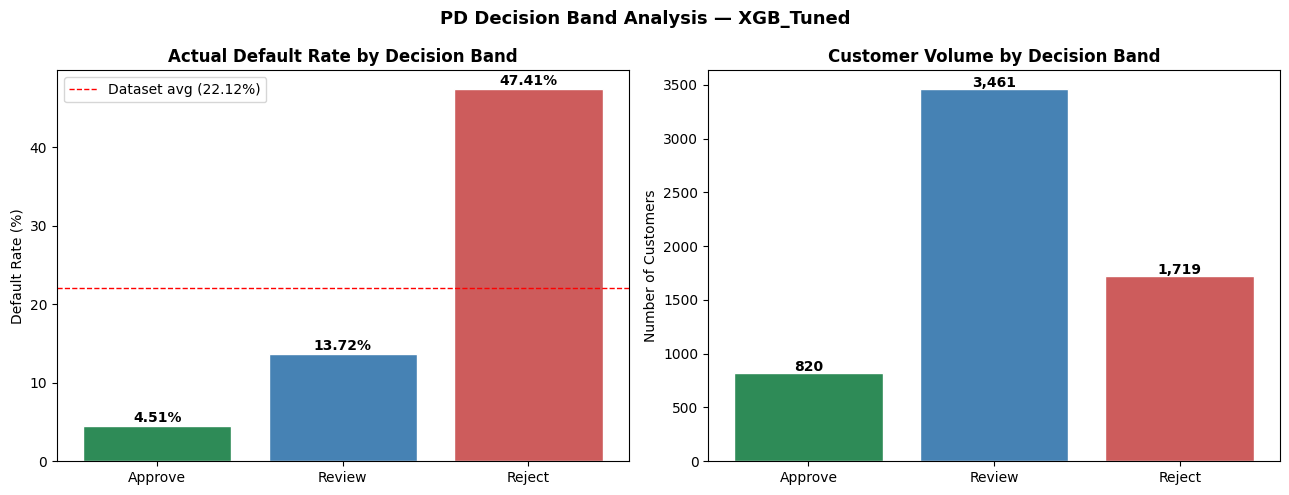

In [79]:
# =============================================================================
# PD OUTPUT - FULL TEST SET ANALYSIS BY DECISION BAND
# =============================================================================

section("PD output - full test set analysis by decision band")

# summary by decision band
band_summary = pd.DataFrame({
    "Count":        pd_results.groupby("Decision")["Actual_Default"].count(),
    "Actual_Defaults": pd_results.groupby("Decision")["Actual_Default"].sum(),
    "Default_Rate_%": pd_results.groupby("Decision")["Actual_Default"].mean().mul(100).round(2),
    "Mean_PD":      pd_results.groupby("Decision")["PD"].mean().round(4),
    "Min_PD":       pd_results.groupby("Decision")["PD"].min().round(4),
    "Max_PD":       pd_results.groupby("Decision")["PD"].max().round(4),
})

# reorder bands logically
band_summary = band_summary.reindex(["Approve", "Review", "Reject"])
print("=== Decision Band Summary ===")
print(band_summary.to_string())

# misclassification analysis
print("\n=== Missed Default by Band ===")
for band in ["Approve", "Review", "Reject"]:
    subset = pd_results[pd_results["Decision"] == band]
    missed = subset[subset["Actual_Default"] == 1]
    print(f"{band:8s} — {len(missed):4d} actual defaulters out of {len(subset):4d} customers ({len(missed)/len(subset)*100:.1f}%)")

# lift calculation
print("\n=== Lift vs Population Average (22.12%) ===")
pop_avg = 0.2212
for band in ["Approve", "Review", "Reject"]:
    rate = pd_results[pd_results["Decision"] == band]["Actual_Default"].mean()
    lift = rate / pop_avg
    print(f"{band:8s} — actual default rate: {rate*100:.1f}%  |  lift: {lift:.2f}x")

# visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# bar chart — default rate by band
colors = ["seagreen", "steelblue", "indianred"]
axes[0].bar(band_summary.index, band_summary["Default_Rate_%"], color=colors, edgecolor="white")
axes[0].axhline(y=22.12, color="red", linestyle="--", linewidth=1, label="Dataset avg (22.12%)")
axes[0].set_title("Actual Default Rate by Decision Band", fontweight="bold")
axes[0].set_ylabel("Default Rate (%)")
axes[0].legend()
for i, (band, row) in enumerate(band_summary.iterrows()):
    axes[0].text(i, row["Default_Rate_%"] + 0.5, f"{row['Default_Rate_%']}%",
                 ha="center", fontsize=10, fontweight="bold")

# bar chart — volume by band
axes[1].bar(band_summary.index, band_summary["Count"], color=colors, edgecolor="white")
axes[1].set_title("Customer Volume by Decision Band", fontweight="bold")
axes[1].set_ylabel("Number of Customers")
for i, (band, row) in enumerate(band_summary.iterrows()):
    axes[1].text(i, row["Count"] + 20, f"{int(row['Count']):,}",
                 ha="center", fontsize=10, fontweight="bold")

plt.suptitle("PD Decision Band Analysis — XGB_Tuned", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pd_decision_band_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Main Findings

- PAY_0 is the strongest single predictor - default rate jumps from 12.8% (on-time) to 75.8% (3 months late)
- Log-transforming skewed features improved Logistic Regression AUC from 0.7115 to 0.7452
- XGB_Tuned and RF_Tuned statistically equivalent across four tests — final selection based on operational criteria
- XGB_Tuned selected - highest recall (61.5%), smallest train-test gap (0.031 vs 0.131), lowest fold variance
- Hyperparameter tuning produced no statistically significant improvement for any model
- Brier score 0.1809 confirms meaningful PD estimates - Platt scaling needed before regulatory reporting
- SHAP confirmed PAY_0 dominates predictions - MARRIAGE and SEX in top 20 features, fairness audit required

## PD Decision Band Results

| Band | PD Range | Customers | Predicted Defaulters | Actual Defaulters | Default Rate |
|------|----------|-----------|----------------------|-------------------|--------------|
| Approve | < 0.20 | 820 | 0 | 37 | 4.5% |
| Review | 0.20–0.50 | 3,461 | 0 | 475 | 13.7% |
| Reject | ≥ 0.50 | 1,719 | 1,719 | 815 | 47.4% |

Only 37 of 1,327 actual defaulters (2.8%) reached the Approve band - a false negative rate of 0.6% across the full test population.

In [80]:
# =============================================================================
# MISCLASSIFICATION ANALYSIS — DEFAULTERS NOT REJECTED
# =============================================================================

section("Defaulters in Approve and Review bands")

missed_defaulters = pd_results[
    (pd_results["Actual_Default"] == 1) & 
    (pd_results["Decision"].isin(["Approve", "Review"]))
].sort_values(by="PD")

print(f"Total defaulters not rejected: {len(missed_defaulters)}")
print(f"  - In Approve band: {(missed_defaulters['Decision'] == 'Approve').sum()}")
print(f"  - In Review band:  {(missed_defaulters['Decision'] == 'Review').sum()}")

print("\n=== All defaulters in Approve / Review bands ===")
print(missed_defaulters[["Actual_Default", "PD", "Decision"]].to_string())


Defaulters in Approve and Review bands
Total defaulters not rejected: 512
  - In Approve band: 37
  - In Review band:  475

=== All defaulters in Approve / Review bands ===
       Actual_Default        PD Decision
982                 1  0.079023  Approve
10732               1  0.103560  Approve
28993               1  0.116136  Approve
16276               1  0.122202  Approve
10649               1  0.126076  Approve
22262               1  0.126995  Approve
5286                1  0.127447  Approve
6853                1  0.133142  Approve
13401               1  0.136124  Approve
10670               1  0.147135  Approve
22711               1  0.151905  Approve
18898               1  0.154157  Approve
8958                1  0.156270  Approve
8541                1  0.157207  Approve
15548               1  0.157437  Approve
23307               1  0.158984  Approve
970                 1  0.161872  Approve
5001                1  0.172338  Approve
7092                1  0.173029  Approve
3980  